# Evaluation of Wind Forecasting Models Against ERA5 and Station Observations, 2016–2022 (Extended to +72h, Bilinear Interpolation)

## 1. Aim and Analysis Questions

This notebook evaluates wind speed forecasts from **FCN3**, **GraphCast**, and **HRES** for 12
meteorological stations over 2016–2022. Unlike the companion `model_comparison_analysis.ipynb`
(lead times +6h to +24h), this notebook uses the extended `_72h` forecast runs and covers the
full 6-hourly lead ladder from **+6h to +72h** (13 lead times). ERA5 is used as the
input/reference dataset, and station-based wind measurements are used as the main observational
benchmark.

**Spatial matching in this notebook uses bilinear interpolation** to each station's exact
coordinates (`xarray.interp(..., method="linear")`), matching the approach used by
[stationbench](https://github.com/juaAI/stationbench), instead of snapping to the nearest
0.25° grid cell. FCN3 and GraphCast values come from the `_interp` forecast runs
(`forecasting.py`'s `--extraction interp`, which interpolates before the raw global grid is
discarded); ERA5 and HRES are interpolated directly by this notebook's loaders. The companion
notebook `model_comparison_analysis_72h.ipynb` is the nearest-neighbor version and is unchanged.

The analysis focuses on:

1. Overall model performance across all stations and years.
2. Performance differences between models.
3. Performance variation by forecast lead time, out to +72h.
4. Station-wise and year-wise error patterns.
5. Important high-wind cases at selected coastal stations.

Full evaluation period: **2016–2022**.

## 2. Data Description

### 2.1 Forecast datasets

The evaluated forecast models are **FCN3**, **GraphCast**, and **HRES**. All three are matched to
each of the 12 stations via bilinear interpolation (`method="linear"`), rather than
nearest-neighbor grid-cell lookup, and evaluated at lead times
+6h to +72h in 6-hour increments (6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72 h — 13 lead times total), using the extended
`FCN3_72h` / `GraphCast_72h` forecast runs (`NSTEPS_LONG=12`, see `config.py`).

- FCN3 and GraphCast are run here at the **same cadence**: daily 00:00 UTC initialization only.
  GraphCast is natively a 6-hourly model, but is restricted to 00:00 UTC here so both ML models
  are compared against HRES on an identical set of verification events (see
  `graphcast_case_study_analysis.ipynb` for the full 6-hourly GraphCast evaluation).
- HRES is ECMWF's operational forecast, natively initialized at 00:00 **and** 12:00 UTC. Both
  init cycles are kept in this notebook (HRES is not restricted to 00:00 UTC), so HRES has more
  matched samples per lead time than FCN3/GraphCast — this is visible in the data availability
  section below.
- FCN3 and GraphCast station values are extracted at forecast-generation time via
  `forecasting.py::_extract_station_wind_interp` (bilinear interpolation), not re-derived here —
  the full global-grid forecast is discarded immediately after extraction, so this notebook reads
  already-interpolated station zarrs (`FCN3_72h_interp` / `GraphCast_72h_interp`).

### 2.2 ERA5 data

ERA5 is used as the input/reference atmospheric dataset. It provides gridded (0.25°), 6-hourly
reanalysis 10 m wind fields and is used for comparison with both model forecasts and station
observations.

### 2.3 Station observations

Station observations (hourly, from the Frost API) are used as the main ground-truth benchmark
for local wind conditions. These measurements represent near-surface wind at specific point
locations and may capture local terrain and coastal effects that are not fully resolved by
gridded forecast products at 0.25° resolution.

In [1]:
import sys
# scipy (required for .interp(method='linear')) lives here instead of the env's own
# site-packages, because /cluster/projects/nn8106k has run out of inodes — see project notes.
sys.path.insert(0, '/cluster/work/projects/nn8106k/siyan/pip_cache')

import warnings
warnings.filterwarnings('ignore')

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
ERA5_DIR  = Path('/cluster/work/projects/nn8106k/siyan/era5_6h')
FC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/FCN3_72h_interp')
GC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/GraphCast_72h_interp')
OBS_DIR   = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')
OUT_ROOT  = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study')
FIG_DIR   = OUT_ROOT / 'figures_72h_interp'
FIG_DIR.mkdir(parents=True, exist_ok=True)

HRES_ZARR = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')

CSV_MASTER   = OUT_ROOT / 'master_forecast_dataset_72h_interp.csv'
CSV_ERA5_OBS = OUT_ROOT / 'era5_vs_obs_dataset_interp.csv'
CSV_HW_MERGED = OUT_ROOT / 'merged_fcn3_graphcast_hres_obs_all_years_72h_interp.csv'

# ── Experiment config ──────────────────────────────────────────────────────────
YEARS         = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
LEAD_HOURS    = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]
HIGH_WIND_THR = 10.8   # m/s — 9-12 m/s bin (near-gale/gale, Beaufort 9-12)

MODEL_ORDER = ['FCN3', 'GraphCast', 'HRES']
REF_ORDER   = ['obs', 'era5']
METRICS     = ['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']

STATIONS = [
    {'id': 'SN88690', 'name': 'Hekkingen Fyr',     'lat': 69.6005, 'lon': 17.8317, 'county': 'Troms',    'obs_base': 'SN88690_Hekkingen_Fyr'},
    {'id': 'SN90490', 'name': 'Tromsø-Langnes',     'lat': 69.6767, 'lon': 18.9133, 'county': 'Troms',    'obs_base': 'SN90490_Tromsoe_Langnes'},
    {'id': 'SN90760', 'name': 'Fakken',             'lat': 70.1043, 'lon': 20.1145, 'county': 'Troms',    'obs_base': 'SN90760_Fakken'},
    {'id': 'SN90800', 'name': 'Torsvåg Fyr',        'lat': 70.2450, 'lon': 19.5000, 'county': 'Troms',    'obs_base': 'SN90800_Torsvag_Fyr'},
    {'id': 'SN90720', 'name': 'Måsvik',             'lat': 69.9900, 'lon': 18.6940, 'county': 'Troms',    'obs_base': 'SN90720_Masvik'},
    {'id': 'SN91740', 'name': 'Sørkjosen Lufthavn', 'lat': 69.7900, 'lon': 20.9520, 'county': 'Troms',    'obs_base': 'SN91740_Sorkjosen_Lufthavn'},
    {'id': 'SN89350', 'name': 'Bardufoss',          'lat': 69.0580, 'lon': 18.5440, 'county': 'Troms',    'obs_base': 'SN89350_Bardufoss'},
    {'id': 'SN87110', 'name': 'Andøya',             'lat': 69.3070, 'lon': 16.1310, 'county': 'Nordland', 'obs_base': 'SN87110_Andoya'},
    {'id': 'SN85380', 'name': 'Skrova Fyr',         'lat': 68.1530, 'lon': 14.6490, 'county': 'Nordland', 'obs_base': 'SN85380_Skrova_Fyr'},
    {'id': 'SN94500', 'name': 'Fruholmen Fyr',      'lat': 71.0940, 'lon': 23.9840, 'county': 'Finnmark', 'obs_base': 'SN94500_Fruholmen_Fyr'},
    {'id': 'SN96400', 'name': 'Slettnes Fyr',       'lat': 71.0890, 'lon': 28.2170, 'county': 'Finnmark', 'obs_base': 'SN96400_Slettnes_Fyr'},
    {'id': 'SN95350', 'name': 'Banak',              'lat': 70.0600, 'lon': 24.9790, 'county': 'Finnmark', 'obs_base': 'SN95350_Banak'},
]
STATIONS_BY_ID = {s['id']: s for s in STATIONS}
STATION_ORDER  = [s['id'] for s in STATIONS]
STATION_LABELS = [s['name'] for s in STATIONS]

# Coastal lighthouse ("Fyr") stations — used to highlight high-wind cases at
# exposed coastal sites in the last section.
COASTAL_STATIONS = [s['id'] for s in STATIONS if 'Fyr' in s['name']]

# Stations flagged in project notes as sitting in complex coastal terrain,
# where grid-based spatial matching to the 0.25° model grid is least reliable
# (bilinear interpolation reduces but does not eliminate this).
COMPLEX_TERRAIN_STATIONS = ['SN88690', 'SN90490']  # Hekkingen Fyr, Tromsø-Langnes

CLR = {
    'FCN3':      '#2196F3',  # blue
    'GraphCast': '#4CAF50',  # green
    'HRES':      '#FF9800',  # orange
    'ERA5':      '#8E44AD',
    'Obs':       '#607D8B',
}
COUNTY_CLR = {'Troms': '#2980B9', 'Nordland': '#E74C3C', 'Finnmark': '#27AE60'}

# Terrain/exposure classification (5 groups), used to compare between-group vs
# within-group model differences in Section 20.3.
# Revised terrain classification (see tab:station_characteristics in the paper) — the
# earlier "Island" category was dropped and its 4 stations reassigned to Fjord/Marine
# Coast/Coastal Ridge based on their actual terrain characteristics.
TERRAIN_ORDER = ['Fjord', 'Marine Coast', 'Coastal Ridge', 'Valley']
TERRAIN_CATEGORY = {
    'SN91740': 'Fjord',                     # Sørkjosen Lufthavn
    'SN95350': 'Fjord',                     # Banak
    'SN90720': 'Fjord',                     # Måsvik
    'SN90490': 'Fjord',                     # Tromsø-Langnes
    'SN87110': 'Marine Coast',  # Andøya
    'SN96400': 'Marine Coast',  # Slettnes Fyr
    'SN90800': 'Marine Coast',  # Torsvåg Fyr
    'SN85380': 'Marine Coast',  # Skrova Fyr
    'SN88690': 'Coastal Ridge',              # Hekkingen Fyr
    'SN94500': 'Coastal Ridge',              # Fruholmen Fyr
    'SN90760': 'Coastal Ridge',              # Fakken
    'SN89350': 'Valley',                    # Bardufoss
}
TERRAIN_CLR = {
    'Fjord':                    '#B3CDE3',
    'Marine Coast':             '#CCEBC5',
    'Coastal Ridge':            '#FED9A6',
    'Valley':                   '#FFFFCC',
}

print(f'Config loaded (bilinear-interpolation notebook). YEARS={YEARS}  LEAD_HOURS={LEAD_HOURS}  HIGH_WIND_THR={HIGH_WIND_THR} m/s')

Config loaded (bilinear-interpolation notebook). YEARS=[2016, 2017, 2018, 2019, 2020, 2021, 2022]  LEAD_HOURS=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]  HIGH_WIND_THR=10.8 m/s


## 3. Station Metadata and Map

12 stations across Troms, Nordland and Finnmark, all in distinct 0.25° grid cells.

**Data gap:** elevation and a formal terrain classification are not currently available for
these stations — the table below shows what is tracked (ID, name, coordinates, region). As a
rough proxy, stations named "*Fyr*" are coastal lighthouses (see `COASTAL_STATIONS`); the rest
are airports or inland/town sites.

Two stations are flagged in project notes as sitting in complex coastal terrain where
grid-based spatial matching should be inspected carefully (bilinear interpolation reduces
but does not eliminate this): **Tromsø-Langnes**
and **Hekkingen Fyr** (highlighted with a red ring on the map).

In [2]:
import os
from pathlib import Path

for line in Path("/cluster/home/siyan/github/WF-experiments/.env").read_text().splitlines():
    if line.strip() and not line.startswith("#") and "=" in line:
        k, v = line.split("=", 1)
        os.environ.setdefault(k.strip(), v.strip())


In [3]:
station_table = pd.DataFrame([
    {'ID': s['id'], 'Name': s['name'], 'Latitude': s['lat'], 'Longitude': s['lon'],
     'Region': s['county'],
     'Coastal (Fyr)': 'Yes' if s['id'] in COASTAL_STATIONS else '',
     'Complex terrain flag': 'Yes' if s['id'] in COMPLEX_TERRAIN_STATIONS else ''}
    for s in STATIONS
])
display(station_table)

,ID,Name,Latitude,Longitude,Region,Coastal (Fyr),Complex terrain flag
0,SN88690,Hekkingen Fyr,69.6005,17.8317,Troms,Yes,Yes
1,SN90490,Tromsø-Langnes,69.6767,18.9133,Troms,,Yes
2,SN90760,Fakken,70.1043,20.1145,Troms,,
3,SN90800,Torsvåg Fyr,70.2450,19.5000,Troms,Yes,
4,SN90720,Måsvik,69.9900,18.6940,Troms,,
5,SN91740,Sørkjosen Lufthavn,69.7900,20.9520,Troms,,
6,SN89350,Bardufoss,69.0580,18.5440,Troms,,
7,SN87110,Andøya,69.3070,16.1310,Nordland,,
8,SN85380,Skrova Fyr,68.1530,14.6490,Nordland,Yes,
9,SN94500,Fruholmen Fyr,71.0940,23.9840,Finnmark,Yes,


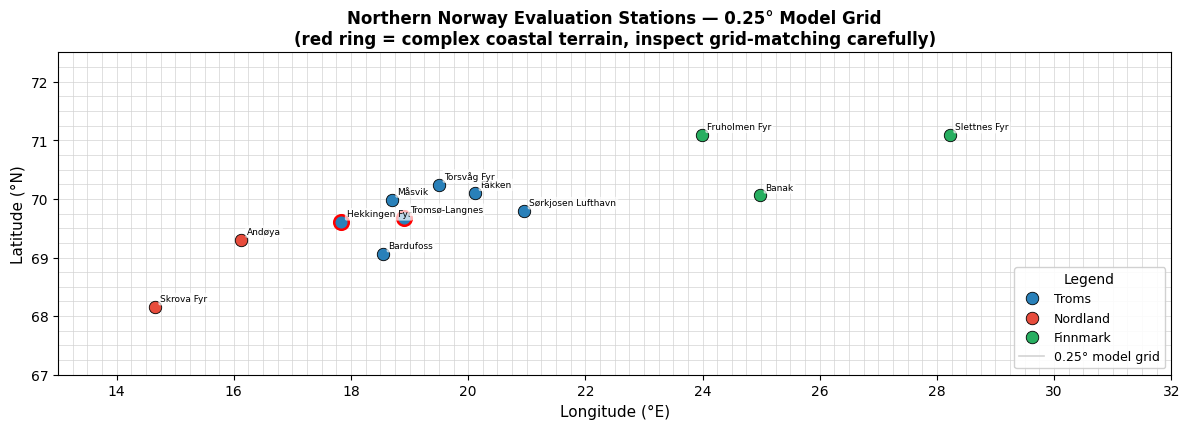

In [4]:
lon_min, lon_max, lat_min, lat_max = 13.0, 32.0, 67.0, 72.5
fig, ax = plt.subplots(figsize=(12, 7))
res = 0.25
for lon in np.arange(np.ceil(lon_min / res) * res, lon_max + res, res):
    ax.axvline(lon, color='lightgray', lw=0.5, zorder=1)
for lat in np.arange(np.ceil(lat_min / res) * res, lat_max + res, res):
    ax.axhline(lat, color='lightgray', lw=0.5, zorder=1)

for st in STATIONS:
    clr = COUNTY_CLR[st['county']]
    is_flagged = st['id'] in COMPLEX_TERRAIN_STATIONS
    ax.scatter(st['lon'], st['lat'], color=clr, s=110 if is_flagged else 80, zorder=4,
               edgecolors='red' if is_flagged else 'black',
               linewidths=1.8 if is_flagged else 0.6)
    ax.annotate(st['name'], xy=(st['lon'], st['lat']),
                xytext=(4, 4), textcoords='offset points', fontsize=6.5, zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)
ax.set_xlabel('Longitude (°E)', fontsize=11); ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_title('Northern Norway Evaluation Stations — 0.25° Model Grid\n(red ring = complex coastal terrain, inspect grid-matching carefully)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

county_order = list(dict.fromkeys(st['county'] for st in STATIONS))
county_handles = [plt.Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=COUNTY_CLR[c],
                              markeredgecolor='black', markeredgewidth=0.6, markersize=9, label=c)
                   for c in county_order]
grid_handle = plt.Line2D([0], [0], color='lightgray', lw=1.2, label='0.25° model grid')
ax.legend(handles=county_handles + [grid_handle], title='Legend', fontsize=9, loc='lower right', framealpha=0.9)
ax.set_aspect('equal', adjustable='box'); ax.grid(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_map_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import os
import requests
from pathlib import Path

OUT_DIR = Path("../outputs/map_data")
OUT_DIR.mkdir(exist_ok=True)

out_path = OUT_DIR / "dem_northern_norway_cop90.tif"

# Bounding box covering all 12 stations across Northern Norway
south = 67.5
north = 71.7
west  = 13.0
east  = 29.5

if out_path.exists():
    print(f"Cached, skipping download: {out_path}")
    print(f"File size: {out_path.stat().st_size / 1024 / 1024:.2f} MB")
else:
    API_KEY = os.environ["OPENTOPOGRAPHY_API_KEY"]

    url = "https://portal.opentopography.org/API/globaldem"

    params = {
        "demtype": "COP90",          # Copernicus DEM GLO-90 (90 m) — ~9x smaller than COP30
        "south": south,
        "north": north,
        "west": west,
        "east": east,
        "outputFormat": "GTiff",
        "API_Key": API_KEY,
    }

    r = requests.get(url, params=params, timeout=300)
    r.raise_for_status()

    out_path.write_bytes(r.content)

    print(f"Saved: {out_path}")
    print(f"File size: {out_path.stat().st_size / 1024 / 1024:.2f} MB")


Cached, skipping download: ../outputs/map_data/dem_northern_norway_cop90.tif
File size: 180.58 MB


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from IPython.display import Image, display

_MAP_FIG_DIR = Path("images")
_MAP_FIG_DIR.mkdir(exist_ok=True)

_station_map_png = _MAP_FIG_DIR / "station_map_all.png"
_station_map_pdf = _MAP_FIG_DIR / "station_map_all.pdf"

_MAP_STATIONS = [
    {'id': 'SN88690', 'name': 'HEKKINGEN FYR',     'lat': 69.6005, 'lon': 17.8317},
    {'id': 'SN90490', 'name': 'TROMSØ - LANGNES',  'lat': 69.6767, 'lon': 18.9133},
    {'id': 'SN90760', 'name': 'FAKKEN',             'lat': 70.1043, 'lon': 20.1145},
    {'id': 'SN90800', 'name': 'TORSVÅG FYR',        'lat': 70.2450, 'lon': 19.5000},
    {'id': 'SN90720', 'name': 'MÅSVIK',             'lat': 69.9900, 'lon': 18.6940},
    {'id': 'SN91740', 'name': 'SØRKJOSEN LUFTHAVN', 'lat': 69.7900, 'lon': 20.9520},
    {'id': 'SN89350', 'name': 'BARDUFOSS',          'lat': 69.0580, 'lon': 18.5440},
    {'id': 'SN87110', 'name': 'ANDØYA',             'lat': 69.3070, 'lon': 16.1310},
    {'id': 'SN85380', 'name': 'SKROVA FYR',         'lat': 68.1530, 'lon': 14.6490},
    {'id': 'SN94500', 'name': 'FRUHOLMEN FYR',      'lat': 71.0940, 'lon': 23.9840},
    {'id': 'SN96400', 'name': 'SLETTNES FYR',       'lat': 71.0890, 'lon': 28.2170},
    {'id': 'SN95350', 'name': 'BANAK',              'lat': 70.0600, 'lon': 24.9790},
]

# Color by terrain group (TERRAIN_CATEGORY, defined in the config cell) — same terrain,
# same color, instead of one distinct color per station. Uses its own saturated palette
# (MAP_MARKER_CLR) rather than the pastel TERRAIN_CLR used for background shading
# elsewhere (Figure 1 panel b, Section 20.3) — pastel fills are too washed out to read
# as solid marker colors against the DEM background.
MAP_MARKER_CLR = {
    'Fjord':         '#1f77b4',  # blue
    'Marine Coast':  '#17becf',  # teal/cyan
    'Coastal Ridge': '#ff7f0e',  # orange
    'Valley':        '#9467bd',  # purple
}
station_colors = {s['id']: MAP_MARKER_CLR[TERRAIN_CATEGORY[s['id']]] for s in _MAP_STATIONS}

dem_path = "../outputs/map_data/dem_northern_norway_cop90.tif"

# Shared with the zoom-inset panels below (cell using _plot_zoom_panel), so these stay
# defined even when the main map itself is skipped as already-rendered.
ocean_color = "#d8ecff"
base = plt.get_cmap("terrain")
_cmap_colors = base(np.linspace(0.16, 1.0, 256))
_low_color = np.array([0.92, 0.85, 0.74, 1.0])
_cmap_colors[:30] = _low_color
cmap = LinearSegmentedColormap.from_list("terrain_soft_low", _cmap_colors)
cmap.set_bad(alpha=0)

if _station_map_png.exists() and _station_map_pdf.exists():
    print(f"Station map already exists at {_station_map_png}, skipping regeneration.")
    display(Image(filename=str(_station_map_png)))
else:
    # Custom label offsets to avoid overlap in the crowded Tromso cluster. Kept close to the
    # station point (unlike an earlier pass that pushed labels far out to dodge collisions —
    # that fixed overlap but made the map read as too scattered). Dropping the station ID
    # from the label (name only; the ID is still in the station table) roughly halves each
    # box's height, which is what actually makes tight placement work again at fontsize 11.
    label_cfg = {
        'SN90800': {'dx': 0.15,  'dy': 0.12,  'ha': 'left',  'va': 'bottom'},  # TORSVAG FYR - up-right
        'SN90760': {'dx': 0.30,  'dy': -0.02, 'ha': 'left',  'va': 'center'}, # FAKKEN - right
        'SN90720': {'dx': -0.20, 'dy': 0.12,  'ha': 'right', 'va': 'bottom'}, # MASVIK - up-left
        'SN90490': {'dx': 0.12,  'dy': -0.18, 'ha': 'left',  'va': 'top'},    # TROMSO-LANGNES - down-right
        'SN88690': {'dx': -0.28, 'dy': -0.16, 'ha': 'right', 'va': 'top'},    # HEKKINGEN FYR - down-left
        'SN87110': {'dx': 0.05,  'dy': -0.18, 'ha': 'left',  'va': 'top'},    # ANDOYA - down
        'SN89350': {'dx': 0.12,  'dy': -0.16, 'ha': 'left',  'va': 'top'},    # BARDUFOSS - down
        'SN91740': {'dx': 0.20,  'dy': 0.08,  'ha': 'left',  'va': 'bottom'}, # SORKJOSEN LUFTHAVN - up-right
        'SN96400': {'dx': -0.15, 'dy': -0.05, 'ha': 'right', 'va': 'center'}, # SLETTNES FYR - left (near the map's right edge)
    }

    lats = [s['lat'] for s in _MAP_STATIONS]
    lons = [s['lon'] for s in _MAP_STATIONS]

    fig = plt.figure(figsize=(16, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent(
        [min(lons) - 1.2, max(lons) + 1.2, min(lats) - 0.5, max(lats) + 0.5],
        crs=ccrs.PlateCarree()
    )

    ax.set_facecolor(ocean_color)
    ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, edgecolor="none", zorder=0)

    with rasterio.open(dem_path) as src:
        dem = src.read(1).astype(float)
        bounds = src.bounds
        if src.nodata is not None:
            dem[dem == src.nodata] = np.nan
        dem[dem <= 0] = np.nan

        ax.imshow(
            dem,
            origin="upper",
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            alpha=0.78,
            interpolation="bilinear",
            zorder=1
        )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black", zorder=3)

    for s in _MAP_STATIONS:
        color = station_colors[s['id']]
        ax.scatter(
            s['lon'], s['lat'],
            s=170,
            color=color,
            edgecolor="black",
            linewidth=1.1,
            zorder=5,
            transform=ccrs.PlateCarree()
        )
        cfg = label_cfg.get(s['id'], {'dx': 0.12, 'dy': -0.03, 'ha': 'left', 'va': 'top'})
        label_x, label_y = s['lon'] + cfg['dx'], s['lat'] + cfg['dy']
        # Leader line from the station point to its label — needed now that crowded-cluster
        # labels sit well outside the immediate vicinity of their point (see label_cfg above).
        ax.plot(
            [s['lon'], label_x], [s['lat'], label_y],
            color=color, lw=1.3, zorder=4.5, alpha=0.85,
            transform=ccrs.PlateCarree(),
        )
        ax.text(
            label_x, label_y,
            s['name'],
            fontsize=11,
            fontweight='bold',
            transform=ccrs.PlateCarree(),
            ha=cfg['ha'],
            va=cfg['va'],
            bbox=dict(
                facecolor="white",
                edgecolor=color,
                linewidth=1.6,
                alpha=0.95,
                boxstyle="round,pad=0.25"
            ),
            zorder=6
        )

    gl = ax.gridlines(draw_labels=True, linewidth=0.9, alpha=0.6, color="dimgray", linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.MultipleLocator(0.25)
    gl.ylocator = mticker.MultipleLocator(0.25)
    gl.xformatter = LongitudeFormatter(direction_label=False)
    gl.yformatter = LatitudeFormatter(direction_label=False)
    gl.xlabel_style = {"size": 17}
    gl.ylabel_style = {"size": 17}

    ax.text(0.5, -0.12, "Longitude (°E)", transform=ax.transAxes, ha="center", va="top", fontsize=17)
    ax.text(-0.06, 0.5, "Latitude (°N)", transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=17)

    terrain_handles = [Patch(facecolor=MAP_MARKER_CLR[cat], edgecolor='black', linewidth=1.0, label=cat)
                       for cat in TERRAIN_ORDER]
    ax.legend(handles=terrain_handles, title='Terrain group', fontsize=13, title_fontsize=14,
              loc='upper left', framealpha=0.95)

    plt.tight_layout()

    plt.savefig(_station_map_pdf, bbox_inches="tight")
    plt.savefig(_station_map_png, dpi=400, bbox_inches="tight")
    plt.show()


In [7]:
# 3.x Download high-resolution (COP30, 30 m) local DEM crops per station, for the
# zoom-in inset figure below — the whole-region COP90 (90 m) DEM used in the main map
# above is too coarse to show local topography (fjords, ridges, valley walls) at the
# scale of an individual station site.
import os
import requests
from pathlib import Path

_ZOOM_DEM_DIR = Path("../outputs/map_data/zoom_insets")
_ZOOM_DEM_DIR.mkdir(parents=True, exist_ok=True)

# Half-width of each station's local crop, in degrees — chosen to give a roughly
# square ~25 km x 25 km box at this latitude (1 deg longitude is much shorter than
# 1 deg latitude at ~70N, hence the smaller lat half-width).
LAT_HALF_WIDTH = 0.12
LON_HALF_WIDTH = 0.35

API_KEY = os.environ["OPENTOPOGRAPHY_API_KEY"]
url = "https://portal.opentopography.org/API/globaldem"

for s in _MAP_STATIONS:
    out_path = _ZOOM_DEM_DIR / f"dem_{s['id']}_cop30.tif"
    if out_path.exists():
        print(f"Cached, skipping: {out_path.name}  ({out_path.stat().st_size / 1024:.0f} KB)")
        continue
    params = {
        "demtype": "COP30",
        "south": s['lat'] - LAT_HALF_WIDTH,
        "north": s['lat'] + LAT_HALF_WIDTH,
        "west":  s['lon'] - LON_HALF_WIDTH,
        "east":  s['lon'] + LON_HALF_WIDTH,
        "outputFormat": "GTiff",
        "API_Key": API_KEY,
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    out_path.write_bytes(r.content)
    print(f"Saved: {out_path.name}  ({out_path.stat().st_size / 1024:.0f} KB)")


NameError: name '_MAP_STATIONS' is not defined

In [ ]:
# 3.x Figure: zoom-in local-topography insets, one per station (for appendix — resolves
# the "difficult to see local topography" comment on the main map above). Each panel
# uses the station's own COP30 crop, plotted at a much tighter extent than the main
# map, so local terrain features are actually visible.

def _plot_zoom_panel(ax, s):
    """Draw one station's zoomed local-topography panel onto `ax`. Shared by the
    combined grid figure and the individual per-station figures below, so both stay
    visually identical."""
    dem_path = _ZOOM_DEM_DIR / f"dem_{s['id']}_cop30.tif"
    color = station_colors[s['id']]

    ax.set_extent(
        [s['lon'] - LON_HALF_WIDTH, s['lon'] + LON_HALF_WIDTH,
         s['lat'] - LAT_HALF_WIDTH, s['lat'] + LAT_HALF_WIDTH],
        crs=ccrs.PlateCarree()
    )
    ax.set_facecolor(ocean_color)
    ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, edgecolor="none", zorder=0)

    with rasterio.open(dem_path) as src:
        dem = src.read(1).astype(float)
        bounds = src.bounds
        if src.nodata is not None:
            dem[dem == src.nodata] = np.nan
        dem[dem <= 0] = np.nan
        ax.imshow(
            dem, origin="upper",
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            transform=ccrs.PlateCarree(), cmap=cmap, alpha=0.85,
            interpolation="bilinear", zorder=1,
        )

    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black", zorder=3)
    ax.scatter(s['lon'], s['lat'], s=80, color=color, edgecolor="black",
               linewidth=1.0, zorder=5, transform=ccrs.PlateCarree())

    ax.gridlines(draw_labels=False, linewidth=0.6, alpha=0.5, color="dimgray", linestyle="--")


# Panels are wide/short (PlateCarree keeps 1 deg lon == 1 deg lat on screen, and the
# station boxes are much wider in longitude than latitude at this latitude), so a tall
# figsize with default spacing leaves large vertical gaps between rows — use a shorter
# figure and tighter hspace to match.
fig, axes = plt.subplots(
    3, 4, figsize=(18, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
)
plt.subplots_adjust(hspace=0.05, wspace=0.08)

for ax, s in zip(axes.flat, _MAP_STATIONS):
    _plot_zoom_panel(ax, s)

for ax in axes.flat[len(_MAP_STATIONS):]:
    ax.axis('off')

terrain_handles = [Patch(facecolor=MAP_MARKER_CLR[cat], edgecolor='black', linewidth=1.0, label=cat)
                   for cat in TERRAIN_ORDER]
fig.legend(handles=terrain_handles, title='Terrain group', fontsize=20, title_fontsize=14,
           loc='lower center', ncol=len(TERRAIN_ORDER), bbox_to_anchor=(0.5, -0.02), framealpha=0.95)

# fig.suptitle('Local Topography at Each Station', fontsize=23, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(_MAP_FIG_DIR / "station_zoom_insets_appendix.pdf", bbox_inches="tight")
plt.savefig(_MAP_FIG_DIR / "station_zoom_insets_appendix.png", dpi=300, bbox_inches="tight")
plt.show()

# Also save each station's zoom panel as its own standalone figure — useful if the
# combined grid above renders too small in the paper and a single station needs to be
# shown at full size instead.
_ZOOM_SINGLE_DIR = _MAP_FIG_DIR / "zoom_insets_individual"
_ZOOM_SINGLE_DIR.mkdir(exist_ok=True)

for s in _MAP_STATIONS:
    fig_s, ax_s = plt.subplots(figsize=(6, 3.2), subplot_kw={'projection': ccrs.PlateCarree()})
    _plot_zoom_panel(ax_s, s)
    plt.tight_layout()
    plt.savefig(_ZOOM_SINGLE_DIR / f"zoom_{s['id']}.png", dpi=300, bbox_inches="tight")
    plt.savefig(_ZOOM_SINGLE_DIR / f"zoom_{s['id']}.pdf", bbox_inches="tight")
    plt.close(fig_s)

print(f"Saved {len(_MAP_STATIONS)} individual zoom panels to {_ZOOM_SINGLE_DIR}")


## 4. Data Preprocessing

### 4.1–4.3 Load forecasts, ERA5, and station observations

Standardized per-source loaders, each returning `(station, valid_time, ...)`:

- Forecasts: `(station, valid_time, lead_h, forecast_wind)`
- ERA5: `(station, valid_time, era5_wind)`
- Station obs: `(station, valid_time, obs_wind)`

### 4.4 Time alignment

Forecasts, ERA5, and station observations are matched by **valid time**: for each forecast
initialization and lead time, the forecast valid time is compared with ERA5 and the station
observation at that same timestamp. The result is one master dataframe:

`init_time | lead_h | valid_time | station | model | forecast | era5 | obs | year`

This is the single dataframe basically everything below is computed from.

In [ ]:
def load_obs(year: int) -> pd.DataFrame:
    """Load hourly station wind speed from Frost API CSVs.
    Returns (station, valid_time, obs_wind) — one row per station-hour.
    """
    parts = []
    for st in STATIONS:
        f = OBS_DIR / f"{st['obs_base']}_{year}.csv"
        if not f.exists():
            print(f'  [obs] Missing: {f.name}')
            continue
        df = pd.read_csv(f)
        df['valid_time'] = (pd.to_datetime(df['time'], utc=True)
                              .dt.tz_convert(None))
        df['station']   = st['id']
        df['obs_wind']  = pd.to_numeric(df['wind_speed'], errors='coerce')
        parts.append(
            df[['station', 'valid_time', 'obs_wind']].dropna()
        )
    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'obs_wind'])
    return (pd.concat(parts, ignore_index=True)
              .sort_values('valid_time')
              .reset_index(drop=True))

In [ ]:
# Crop to a small bounding box around the 12 stations *before* interpolating.
# `.interp(method="linear")` needs scipy, and — unlike nearest-neighbor `.sel()` —
# materializes the selected lat/lon slice into memory for every timestep involved.
# Without this crop, each load_era5()/load_hres() call would materialize the
# *entire* global 0.25° grid (721x1440) for every timestep in the slice, which is
# almost certainly what killed the kernel: neither ERA5 nor HRES here are
# dask-backed in this environment (no `dask` package installed), so there is no
# lazy/chunked computation protecting memory — cropping first keeps the
# materialized array to a small regional slice instead of the whole planet.
_STATION_LAT_MARGIN = 2.0  # degrees, wide enough for linear interp's 2 nearest gridpoints
_STATION_LON_MARGIN = 2.0

_lat_min = min(s['lat'] for s in STATIONS) - _STATION_LAT_MARGIN
_lat_max = max(s['lat'] for s in STATIONS) + _STATION_LAT_MARGIN
_lon_min = (min(s['lon'] for s in STATIONS) % 360) - _STATION_LON_MARGIN
_lon_max = (max(s['lon'] for s in STATIONS) % 360) + _STATION_LON_MARGIN


def _crop_to_stations(da: xr.DataArray) -> xr.DataArray:
    """Subset a global lat/lon DataArray to a small box around the 12 stations.

    Handles both ascending and descending latitude/longitude coordinate order
    (ERA5 here is lat-descending, HRES is lat-ascending), since `.sel(slice(...))`
    silently returns an empty selection if the slice direction doesn't match the
    coordinate's own order.
    """
    lat_asc = bool(da.latitude.values[0] < da.latitude.values[-1])
    lon_asc = bool(da.longitude.values[0] < da.longitude.values[-1])
    lat_slice = slice(_lat_min, _lat_max) if lat_asc else slice(_lat_max, _lat_min)
    lon_slice = slice(_lon_min, _lon_max) if lon_asc else slice(_lon_max, _lon_min)
    return da.sel(latitude=lat_slice, longitude=lon_slice)


print(f'Station bounding box for interpolation: lat [{_lat_min:.2f}, {_lat_max:.2f}], '
      f'lon [{_lon_min:.2f}, {_lon_max:.2f}]')

In [ ]:
def load_era5(year: int) -> pd.DataFrame:
    """Extract ERA5 10m wind speed at station locations via bilinear interpolation
    (method='linear'), matching stationbench's spatial-matching approach
    (https://github.com/juaAI/stationbench) instead of nearest-neighbor.
    ERA5 is 6-hourly → valid times at 00:00, 06:00, 12:00, 18:00 UTC.
    Returns (station, valid_time, era5_wind).
    """
    f = ERA5_DIR / f'era5_single_{year}.nc'
    if not f.exists():
        print(f'  [ERA5] Missing: {f.name}')
        return pd.DataFrame(columns=['station', 'valid_time', 'era5_wind'])

    ds  = xr.open_dataset(str(f))
    # Crop BEFORE computing wind speed, not after: without dask in this env,
    # u10**2 + v10**2 forces immediate computation over the FULL global grid
    # (~70s/year measured), vs ~1.6s/year once cropped first.
    u10 = _crop_to_stations(ds['u10'])
    v10 = _crop_to_stations(ds['v10'])
    ws  = np.sqrt(u10 ** 2 + v10 ** 2)   # 10m wind speed

    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    ws_interp = ws.interp(latitude=station_lat, longitude=station_lon, method='linear')

    df = (ws_interp.to_dataframe(name='era5_wind')
          .reset_index()[['station', 'valid_time', 'era5_wind']]
          .dropna(subset=['era5_wind']))
    ds.close()
    return df.sort_values(['station', 'valid_time']).reset_index(drop=True)

In [ ]:
def load_hres(year: int, lead_hours=None, init_hours=(0,)) -> pd.DataFrame:
    """Extract HRES 10m wind speed at station locations via bilinear interpolation
    (method='linear'), matching stationbench's spatial-matching approach
    (https://github.com/juaAI/stationbench) instead of nearest-neighbor.
    HRES is natively initialised at 00:00 and 12:00 UTC, but is restricted here to
    init_hours=(0,) (00 UTC only) by default, matching FCN3/GraphCast's cadence,
    so all three models are compared on the same sample count per lead time
    rather than HRES having ~2x the samples from keeping both init cycles.
    Returns (station, valid_time, lead_h, hres_wind).
    """
    if lead_hours is None:
        lead_hours = LEAD_HOURS
    if isinstance(lead_hours, int):
        lead_hours = [lead_hours]

    if not HRES_ZARR.exists():
        print(f'  [HRES] Not found: {HRES_ZARR}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'hres_wind'])

    ds   = xr.open_zarr(str(HRES_ZARR), consolidated=False)
    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})

    rows = []
    for lh in lead_hours:
        da = ds['10m_wind_speed'].sel(prediction_timedelta=lh)
        da = da.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))
        da = da.isel(time=da['time'].dt.hour.isin(init_hours))  # restrict to 00Z, matching FCN3/GraphCast
        da = _crop_to_stations(da)  # keep the materialized slice small — see helper cell above
        da_interp = da.interp(latitude=station_lat, longitude=station_lon, method='linear')
        df = da_interp.to_dataframe(name='hres_wind').reset_index()
        df['lead_h'] = lh
        df['valid_time'] = df['time'] + pd.Timedelta(hours=lh)
        rows.append(df[['station', 'valid_time', 'lead_h', 'hres_wind']])

    out = pd.concat(rows, ignore_index=True).dropna(subset=['hres_wind'])
    ds.close()
    return out.sort_values(['station', 'valid_time']).reset_index(drop=True)

In [ ]:
def load_fcn3(year: int) -> pd.DataFrame:
    """Load FCN3 +6/+12/+18/+24 h wind from weekly station zarrs.
    00:00 UTC init, 4 steps of 6h → valid at 06:00, 12:00, 18:00, 00:00 UTC.
    Returns (station, valid_time, lead_h, fcn3_wind).
    """
    fc_dir = FC_ROOT / str(year)
    files  = sorted(fc_dir.glob('fcn3_*.zarr'))
    if not files:
        print(f'  [FCN3] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])

    parts = []
    for f in files:
        ds         = xr.open_zarr(str(f))
        sids       = [str(s) for s in ds['station'].values]
        init_times = pd.DatetimeIndex(ds['time'].values)
        lt_hours   = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws         = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i, init_t in enumerate(init_times):
                    val = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'fcn3_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
def load_graphcast(year: int, init_hours=(0,)) -> pd.DataFrame:
    """Load GraphCast +6/+12/+18/+24 h wind from weekly station zarrs.
    GraphCast forecasts are stored at every 6h init (00/06/12/18 UTC), but by
    default only init_hours=(0,) is kept — i.e. daily 00:00 UTC — to match
    FCN3's single daily init and keep the models directly comparable.
    Returns (station, valid_time, lead_h, graphcast_wind).
    """
    fc_dir = GC_ROOT / str(year)
    files  = sorted(fc_dir.glob('graphcast_*.zarr'))
    if not files:
        print(f'  [GraphCast] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])

    parts = []
    for f in files:
        ds            = xr.open_zarr(str(f))
        sids          = [str(s) for s in ds['station'].values]
        init_times_all = pd.DatetimeIndex(ds['time'].values)
        keep_idx      = np.where(init_times_all.hour.isin(init_hours))[0]
        lt_hours      = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws            = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i in keep_idx:
                    init_t = init_times_all[t_i]
                    val    = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'graphcast_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [ ]:
FORCE_RECOMPUTE_MASTER = False

MODEL_LOADERS = {'FCN3': load_fcn3, 'GraphCast': load_graphcast, 'HRES': load_hres}
FORECAST_COL  = {'FCN3': 'fcn3_wind', 'GraphCast': 'graphcast_wind', 'HRES': 'hres_wind'}

if CSV_MASTER.exists() and not FORCE_RECOMPUTE_MASTER:
    master_df = pd.read_csv(CSV_MASTER, parse_dates=['valid_time', 'init_time'])
    print(f'Loaded from cache: {CSV_MASTER.name}  ({len(master_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        era5_df = load_era5(year)
        obs_df  = load_obs(year)
        for df in [era5_df, obs_df]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')

        for model_name, loader in MODEL_LOADERS.items():
            fc_df = loader(year)
            if fc_df.empty:
                print(f'  [{model_name}] no data — skipping')
                continue
            fc_df = fc_df.copy()
            fc_df['valid_time'] = fc_df['valid_time'].astype('datetime64[us]')
            fc_df = fc_df.rename(columns={FORECAST_COL[model_name]: 'forecast'})

            m = fc_df.merge(era5_df, on=['station', 'valid_time'], how='left')
            m = m.merge(obs_df, on=['station', 'valid_time'], how='left')
            m = m.rename(columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
            m['model']     = model_name
            m['year']      = year
            m['init_time'] = m['valid_time'] - pd.to_timedelta(m['lead_h'], unit='h')
            parts.append(m[['init_time', 'lead_h', 'valid_time', 'station', 'model',
                            'forecast', 'era5', 'obs', 'year']])
            print(f'  [{model_name}] {len(m):,} rows  '
                  f'(era5 matched {m["era5"].notna().mean() * 100:.1f}%, '
                  f'obs matched {m["obs"].notna().mean() * 100:.1f}%)')

    master_df = pd.concat(parts, ignore_index=True)
    master_df.to_csv(CSV_MASTER, index=False)
    print(f'\nSaved: {CSV_MASTER}  ({len(master_df):,} rows)')

master_df.head()

## 5. Data Availability and Quality Control

Before computing any metric, check how much valid (forecast, obs) / (forecast, era5) matched
data actually exists — this avoids misleading results from stations or years with too little
data.

In [ ]:
# 5.1 Availability by year and station (% of forecast rows with a matched obs value)
avail = (master_df.groupby(['model', 'station', 'year'])['obs']
         .apply(lambda s: s.notna().mean() * 100)
         .rename('pct_matched_obs')
         .reset_index())

for model in MODEL_ORDER:
    pivot = (avail[avail['model'] == model]
             .pivot(index='station', columns='year', values='pct_matched_obs')
             .reindex(STATION_ORDER))
    pivot.index = STATION_LABELS
    print(f'{model} — % of forecast rows with a matched station observation')
    display(pivot.round(1))

In [ ]:
# 5.2 Missing data summary, grouped by [model, station, year, lead_h]
missing_summary = (master_df.groupby(['model', 'station', 'year', 'lead_h'])
                   .agg(N=('forecast', 'size'),
                        pct_missing_era5=('era5', lambda s: s.isna().mean() * 100),
                        pct_missing_obs=('obs', lambda s: s.isna().mean() * 100))
                   .reset_index())

print('Missing-data summary (first 10 rows) — full table has '
      f'{len(missing_summary):,} rows, one per model x station x year x lead_h')
display(missing_summary.head(10))

worst = missing_summary.sort_values('pct_missing_obs', ascending=False).head(10)
print('\nWorst 10 (model, station, year, lead_h) combos by % missing obs:')
display(worst)

In [ ]:
# 5.3 Basic wind speed distribution — Obs, ERA5, and each model's forecast
fig, ax = plt.subplots(figsize=(10, 6))

obs_vals  = master_df.drop_duplicates(['station', 'valid_time'])['obs'].dropna()
era5_vals = master_df.drop_duplicates(['station', 'valid_time'])['era5'].dropna()
ax.hist(obs_vals, bins=40, density=True, histtype='step', lw=2.2, color=CLR['Obs'], label='Obs')
ax.hist(era5_vals, bins=40, density=True, histtype='step', lw=2.2, color=CLR['ERA5'], label='ERA5')
for model in MODEL_ORDER:
    vals = master_df[master_df['model'] == model]['forecast'].dropna()
    ax.hist(vals, bins=40, density=True, histtype='step', lw=2.0, color=CLR[model], label=model)

ax.set_xlabel('10 m wind speed (m/s)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Wind Speed Distribution — All Stations, All Years', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'wind_speed_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Metric Definitions

$$\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)^2} \qquad
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}|\hat y_i - y_i| \qquad
\mathrm{Bias} = \frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)$$

$$\mathrm{nRMSE} = \frac{\mathrm{RMSE}}{\bar y}\times 100\% \qquad
\mathrm{nBias} = \frac{\mathrm{Bias}}{\bar y}\times 100\% \qquad
r = \mathrm{corr}(\hat y, y)$$

- **RMSE** — average magnitude of error.
- **MAE** — average absolute error, less sensitive to extreme errors than RMSE.
- **Bias** — systematic over- (positive) or under- (negative) estimation.
- **nRMSE / nBias** — RMSE/Bias normalized by the mean of the reference ($\bar y$), useful when
  stations have different average wind speeds.
- **Corr** — Pearson correlation between forecast and reference; checks whether the model
  captures temporal variability, not just the right average magnitude.

```python
METRICS = ["RMSE", "MAE", "Bias", "nRMSE", "nBias", "Corr"]
```

Optional/secondary metrics used later in this notebook: a **skill score** (1 − RMSE(model) /
RMSE(HRES)) in the station-wise section, and a **high-wind conditional RMSE/Bias** in the last
section.

In [ ]:
def compute_group_metrics(df, pred_col, ref_col, group_cols):
    """Grouped RMSE/MAE/Bias/nRMSE/nBias/Corr between pred_col and ref_col."""
    def _agg(g):
        s = g.dropna(subset=[pred_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan,
                               'nRMSE': np.nan, 'nBias': np.nan, 'Corr': np.nan})
        err  = s[pred_col] - s[ref_col]
        rmse = float(np.sqrt((err ** 2).mean()))
        mae  = float(err.abs().mean())
        bias = float(err.mean())
        mean_ref = float(s[ref_col].mean())
        nrmse = rmse / mean_ref * 100 if mean_ref else np.nan
        nbias = bias / mean_ref * 100 if mean_ref else np.nan
        corr  = float(s[pred_col].corr(s[ref_col])) if n > 1 else np.nan
        return pd.Series({'N': n, 'RMSE': rmse, 'MAE': mae, 'Bias': bias,
                           'nRMSE': nrmse, 'nBias': nbias, 'Corr': corr})
    return df.groupby(group_cols).apply(_agg).reset_index()


def rank_models_by_metric(df_metrics, metric='RMSE', ascending=True):
    return df_metrics.groupby('model')[metric].mean().sort_values(ascending=ascending)


def add_station_std(df, pred_col, ref_col, group_cols, metrics=('RMSE', 'Bias')):
    """Standard deviation across stations of the per-(group, station) metric, merged
    onto a [group_cols]-level table as <metric>_std columns. `group_cols` must not
    include 'station' — this measures station-to-station spread, not sampling
    uncertainty of a single estimate (no bootstrap CI is computed anywhere here)."""
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['station'])
    std_df = station_level.groupby(list(group_cols))[list(metrics)].std().reset_index()
    return std_df.rename(columns={m: f'{m}_std' for m in metrics})


def compute_group_metrics_by_station(df, pred_col, ref_col, group_cols,
                                      metrics=('N', 'RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr')):
    """Station-level evaluation: compute metrics per (group_cols + ['station']) first,
    then average across stations within each group_cols combination — every station
    weighted equally regardless of how many samples it contributed, consistent with a
    station-level study design. This replaces pooling all stations' samples together
    before computing a single RMSE (which implicitly weights by sample count per
    station). N is summed across stations (total underlying samples, kept for context);
    every other metric is averaged across the stations present in each group.
    `group_cols` must not already include 'station'."""
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['station'])
    agg = {m: ('sum' if m == 'N' else 'mean') for m in metrics}
    return station_level.groupby(list(group_cols)).agg(agg).reset_index()

## 7. Main Comparison 1 — Forecasts vs Station Observations

This is the main evaluation: how accurate is each model at the locations that actually matter
(the stations), independent of how well the forecast matches the gridded ERA5 field it may have
been initialized from.

In [ ]:
metrics_vs_obs = compute_group_metrics_by_station(master_df, 'forecast', 'obs', ['model', 'lead_h'])
metrics_vs_obs = metrics_vs_obs.merge(
    add_station_std(master_df, 'forecast', 'obs', ['model', 'lead_h'],
                     metrics=('RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr')),
    on=['model', 'lead_h'], how='left')
# RMSE_std / Bias_std above = standard deviation across the 12 stations at that
# (model, lead_h), not a confidence interval on the pooled RMSE/Bias estimate itself.
metrics_vs_obs = metrics_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Overall performance vs Station Obs — grouped by [model, lead_h], station-level evaluation '
      '(each station weighted equally; see compute_group_metrics_by_station)')
display(metrics_vs_obs.round(3))

In [ ]:
# Mean +/- std-across-stations (averaged over lead time) alongside each ranked value.
# std here is station-to-station spread, not a sampling CI on the ranked value itself.
std_by_model = metrics_vs_obs.groupby('model')[['RMSE_std', 'nRMSE_std', 'Bias_std', 'nBias_std', 'Corr_std']].mean()
n_by_model = metrics_vs_obs.groupby('model')['N'].sum()  # total matched samples across all lead times

print('Model ranking (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)')
print('=' * 60)
for metric, ascending in [('RMSE', True), ('nRMSE', True), ('Bias', True), ('nBias', True), ('Corr', False)]:
    ranking = rank_models_by_metric(metrics_vs_obs, metric, ascending)
    print(f'\nRanked by {metric}:')
    for i, (model, val) in enumerate(ranking.items(), 1):
        std_val = std_by_model.loc[model, f'{metric}_std']
        n_val = int(n_by_model.loc[model])
        print(f'  {i}. {model:10s}  {metric}={val:.3f} ± {std_val:.3f} (across stations)  N={n_val:,}')

In [ ]:
# Figures: RMSE, nRMSE, and Bias, nBias vs lead time (Forecasts vs Station Obs)
line_metrics = [('RMSE', 'RMSE (m/s)'), ('nRMSE', 'nRMSE (%)'), ('Bias', 'Bias (m/s)'), ('nBias', 'nBias (%)')]

# Individual figures, one per metric
for metric, ylabel in line_metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    for model in MODEL_ORDER:
        sub = metrics_vs_obs[metrics_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    if metric in ('Bias', 'nBias'):
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Lead Time', fontsize=10)
    # ax.set_title(f'Wind Speed Forecast {metric}\nUsing Station Observations as Reference (2016–2022, All 12 Stations)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'metrics_vs_obs_lead_time_{metric.lower()}.png', dpi=130, bbox_inches='tight')
    plt.savefig(FIG_DIR / f'metrics_vs_obs_lead_time_{metric.lower()}.pdf', bbox_inches='tight')
    plt.show()

# Combined figure, all four metrics side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, ylabel) in zip(axes, line_metrics):
    for model in MODEL_ORDER:
        sub = metrics_vs_obs[metrics_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    if metric in ('Bias', 'nBias'):
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

# fig.suptitle('Forecasts vs Station Obs — RMSE / nRMSE / Bias / nBias by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time.pdf', bbox_inches='tight')
plt.show()

# Combined figure, RMSE and nRMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, ylabel) in zip(axes, [('RMSE', 'RMSE (m/s)'), ('nRMSE', 'nRMSE (%)')]):
    for model in MODEL_ORDER:
        sub = metrics_vs_obs[metrics_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

# fig.suptitle('Forecasts vs Station Obs — RMSE / nRMSE by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time_rmse_nrmse.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time_rmse_nrmse.pdf', bbox_inches='tight')
plt.show()

# Combined figure, Bias and nBias side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, ylabel) in zip(axes, [('Bias', 'Bias (m/s)'), ('nBias', 'nBias (%)')]):
    for model in MODEL_ORDER:
        sub = metrics_vs_obs[metrics_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

# fig.suptitle('Forecasts vs Station Obs — Bias / nBias by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time_bias_nbias.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'metrics_vs_obs_lead_time_bias_nbias.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# add averge RMSE/nRMSE/Bias/nBias table for all models, also add station average metrics
# Station-level metrics computed first so the overall table can show station-to-station std
# alongside the mean, not just the pooled mean on its own.
metrics_vs_obs_by_station = compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'station'])

avg_metrics = (metrics_vs_obs.groupby('model')
               .agg(avg_RMSE=('RMSE', 'mean'),
                    avg_nRMSE=('nRMSE', 'mean'),
                    avg_Bias=('Bias', 'mean'),
                    avg_nBias=('nBias', 'mean'))
               .reset_index())
_std = (metrics_vs_obs_by_station.groupby('model')[['RMSE', 'nRMSE', 'Bias', 'nBias']].std()
        .rename(columns={'RMSE': 'RMSE_std_across_stations', 'nRMSE': 'nRMSE_std_across_stations',
                          'Bias': 'Bias_std_across_stations', 'nBias': 'nBias_std_across_stations'}))
avg_metrics = avg_metrics.merge(_std.reset_index(), on='model', how='left')
print('Average metrics across all lead times (vs Station Obs); *_std_across_stations = spread across the 12 stations, not a CI:')
display(avg_metrics.round(3))
station_avg_metrics = (metrics_vs_obs_by_station.groupby(['model', 'station'])
                        .agg(avg_RMSE=('RMSE', 'mean'),
                             avg_nRMSE=('nRMSE', 'mean'),
                             avg_Bias=('Bias', 'mean'),
                             avg_nBias=('nBias', 'mean'))
                        .reset_index())
station_avg_metrics['station'] = pd.Categorical(station_avg_metrics['station'],
                                                 categories=STATION_ORDER, ordered=True)
station_avg_metrics = station_avg_metrics.sort_values(['model', 'station'])
station_avg_metrics['station'] = station_avg_metrics['station'].map(
    dict(zip(STATION_ORDER, STATION_LABELS)))

print('Average metrics across all lead times, by model and station (vs Station Obs):')
display(station_avg_metrics.round(3))

In [ ]:
# 7.x Statistical significance of model RMSE differences (vs Station Obs)
# A standard t-test assumes normally-distributed RMSE, which doesn't hold here. Station-
# level bootstrap resampling was used to quantify the uncertainty in pairwise RMSE
# differences: the 12 stations (not individual forecast timesteps) are resampled with
# replacement — a cluster bootstrap, since each station's data is treated as one
# resampling unit, not a temporal block bootstrap over individual timesteps. A
# difference is considered statistically significant when the 95% bootstrap confidence
# interval does not include zero.
from itertools import combinations

N_BOOT = 10_000


def station_bootstrap_rmse_diff(df, pred_col, ref_col, group_cols, models=MODEL_ORDER,
                                 n_boot=N_BOOT, seed=0):
    """Cluster (station-level) bootstrap for pairwise RMSE differences.

    For every combination of `group_cols` values and every pair of models, computes
    RMSE per (model, station) first, then resamples the 12 stations with replacement —
    the same resampled station indices are used for both models in a pair, preserving
    the pairing — to build a bootstrap distribution of mean(RMSE_a - RMSE_b) across
    stations. Reports the observed mean difference, a 95% percentile bootstrap CI, and
    whether that CI excludes zero.

    Returns a long-format DataFrame: group_cols + ['model_a', 'model_b', 'n_stations',
    'mean_rmse_diff', 'ci_low', 'ci_high', 'significant_0.05'].
    """
    rng = np.random.default_rng(seed)
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['model', 'station'])
    combos = station_level[group_cols].drop_duplicates() if group_cols else pd.DataFrame([{}])
    rows = []
    for _, key in combos.iterrows():
        sub = station_level
        for c in group_cols:
            sub = sub[sub[c] == key[c]]
        for m1, m2 in combinations(models, 2):
            s1 = sub[sub['model'] == m1].set_index('station')['RMSE']
            s2 = sub[sub['model'] == m2].set_index('station')['RMSE']
            common = s1.index.intersection(s2.index)
            n = len(common)
            if n < 1:
                mean_diff = ci_low = ci_high = p_value = np.nan
            else:
                x, y = s1.loc[common].to_numpy(), s2.loc[common].to_numpy()
                mean_diff = float(np.mean(x - y))
                idx = rng.integers(0, n, size=(n_boot, n))
                boot_diffs = (x[idx] - y[idx]).mean(axis=1)
                ci_low, ci_high = (float(v) for v in np.percentile(boot_diffs, [2.5, 97.5]))
                # Two-sided empirical bootstrap p-value: 2x the smaller tail fraction of
                # the bootstrap distribution on the other side of zero from the observed
                # difference. Consistent with (not independent of) the "CI excludes 0"
                # significance flag below -- at alpha=0.05 the two always agree -- but
                # gives a reportable p-value instead of just a boolean.
                p_value = float(min(1.0, 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())))
            row = {c: key[c] for c in group_cols}
            row.update({'model_a': m1, 'model_b': m2, 'n_stations': n,
                        'mean_rmse_diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high,
                        'p_value': p_value,
                        'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
            rows.append(row)
    return pd.DataFrame(rows)


sig_vs_obs = station_bootstrap_rmse_diff(master_df, 'forecast', 'obs', [])
print(f'Pairwise significance of RMSE differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs Station Obs)')
print('Significant at ~alpha=0.05 when the 95% CI excludes zero.')
display(sig_vs_obs.round(4))


In [ ]:
# 7.y Statistical significance of model Corr (correlation) differences (vs Station Obs)
# Same station-level cluster bootstrap as the RMSE significance test above — Corr is
# computed per (model, station) via compute_group_metrics (already includes a 'Corr'
# column), then the 12 stations are resampled with replacement to build a 95% CI on
# the pairwise Corr difference.
def station_bootstrap_corr_diff(df, pred_col, ref_col, group_cols, models=MODEL_ORDER,
                                 n_boot=N_BOOT, seed=1):
    """Cluster (station-level) bootstrap for pairwise Corr differences — same mechanics
    as station_bootstrap_rmse_diff, applied to the 'Corr' column instead of 'RMSE'.

    Returns a long-format DataFrame: group_cols + ['model_a', 'model_b', 'n_stations',
    'mean_corr_diff', 'ci_low', 'ci_high', 'significant_0.05'].
    """
    rng = np.random.default_rng(seed)
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['model', 'station'])
    combos = station_level[group_cols].drop_duplicates() if group_cols else pd.DataFrame([{}])
    rows = []
    for _, key in combos.iterrows():
        sub = station_level
        for c in group_cols:
            sub = sub[sub[c] == key[c]]
        for m1, m2 in combinations(models, 2):
            s1 = sub[sub['model'] == m1].set_index('station')['Corr'].dropna()
            s2 = sub[sub['model'] == m2].set_index('station')['Corr'].dropna()
            common = s1.index.intersection(s2.index)
            n = len(common)
            if n < 1:
                mean_diff = ci_low = ci_high = p_value = np.nan
            else:
                x, y = s1.loc[common].to_numpy(), s2.loc[common].to_numpy()
                mean_diff = float(np.mean(x - y))
                idx = rng.integers(0, n, size=(n_boot, n))
                boot_diffs = (x[idx] - y[idx]).mean(axis=1)
                ci_low, ci_high = (float(v) for v in np.percentile(boot_diffs, [2.5, 97.5]))
                # Two-sided empirical bootstrap p-value: 2x the smaller tail fraction of
                # the bootstrap distribution on the other side of zero from the observed
                # difference. Consistent with (not independent of) the "CI excludes 0"
                # significance flag below -- at alpha=0.05 the two always agree -- but
                # gives a reportable p-value instead of just a boolean.
                p_value = float(min(1.0, 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())))
            row = {c: key[c] for c in group_cols}
            row.update({'model_a': m1, 'model_b': m2, 'n_stations': n,
                        'mean_corr_diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high,
                        'p_value': p_value,
                        'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
            rows.append(row)
    return pd.DataFrame(rows)


# Each model's own Corr (forecast vs obs, independent per model — not a cross-model
# correlation), averaged across the 12 stations, so the pairwise differences below are
# read against the actual per-model numbers rather than in isolation.
corr_by_model_vs_obs = (compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'station'])
                         .groupby('model')['Corr'].mean().reindex(MODEL_ORDER))
print('Mean Corr per model (forecast vs obs, averaged across the 12 stations):')
display(corr_by_model_vs_obs.round(4).to_frame('Corr'))

sig_corr_vs_obs = station_bootstrap_corr_diff(master_df, 'forecast', 'obs', [])
print(f'\nPairwise significance of Corr differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs Station Obs)')
display(sig_corr_vs_obs.round(4))


In [ ]:
# 7.z Statistical significance of each model's own Corr (is it different from zero?)
# Different question from 7.y above: not "does model A correlate better than model B"
# but "is this model's own Corr(forecast, obs) significantly different from zero" --
# H0: no relationship between this model's forecast and the observations. Each model
# is tested independently (not pairwise). Same station-level cluster bootstrap: resample
# the 12 stations with replacement, recompute mean Corr each draw, and check whether
# the 95% CI excludes zero.
def station_bootstrap_corr_significance(df, pred_col, ref_col, group_cols=(), models=MODEL_ORDER,
                                         n_boot=N_BOOT, seed=3):
    """Cluster (station-level) bootstrap test of whether each model's own Corr is
    significantly different from zero.

    Returns a long-format DataFrame: group_cols + ['model', 'n_stations', 'mean_corr',
    'ci_low', 'ci_high', 'p_value', 'significant_0.05'].
    """
    rng = np.random.default_rng(seed)
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['model', 'station'])
    combos = station_level[group_cols].drop_duplicates() if group_cols else pd.DataFrame([{}])
    rows = []
    for _, key in combos.iterrows():
        sub = station_level
        for c in group_cols:
            sub = sub[sub[c] == key[c]]
        for m in models:
            s = sub[sub['model'] == m].set_index('station')['Corr'].dropna()
            n = len(s)
            if n < 1:
                mean_corr = ci_low = ci_high = p_value = np.nan
            else:
                x = s.to_numpy()
                mean_corr = float(np.mean(x))
                idx = rng.integers(0, n, size=(n_boot, n))
                boot_means = x[idx].mean(axis=1)
                ci_low, ci_high = (float(v) for v in np.percentile(boot_means, [2.5, 97.5]))
                p_value = float(min(1.0, 2 * min((boot_means <= 0).mean(), (boot_means >= 0).mean())))
            row = {c: key[c] for c in group_cols}
            row.update({'model': m, 'n_stations': n, 'mean_corr': mean_corr,
                        'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_value,
                        'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
            rows.append(row)
    return pd.DataFrame(rows)


sig0_corr_vs_obs = station_bootstrap_corr_significance(master_df, 'forecast', 'obs')
print(f'Is each model\'s own Corr significantly different from zero? (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs Station Obs)')
display(sig0_corr_vs_obs.round(4))


## 8. Main Comparison 2 — Forecasts vs ERA5

This answers: *how far does each model deviate from ERA5?* But it does **not** necessarily
measure local station accuracy — ERA5 is gridded and smoother than point observations,
especially in complex terrain and coastal areas. This section separates model deviation from
ERA5 (here) from local forecast error against real station observations (previous section).

In [ ]:
metrics_vs_era5 = compute_group_metrics_by_station(master_df, 'forecast', 'era5', ['model', 'lead_h'])
metrics_vs_era5 = metrics_vs_era5.merge(
    add_station_std(master_df, 'forecast', 'era5', ['model', 'lead_h'],
                     metrics=('RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr')),
    on=['model', 'lead_h'], how='left')
metrics_vs_era5 = metrics_vs_era5.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Overall performance vs ERA5 — grouped by [model, lead_h]')
display(metrics_vs_era5.round(3))

In [ ]:
# Model ranking vs ERA5, mirroring the vs-Station-Obs ranking above (Section 7):
# mean +/- std-across-stations (averaged over lead time), plus total matched N per model.
std_by_model_era5 = metrics_vs_era5.groupby('model')[['RMSE_std', 'nRMSE_std', 'Bias_std', 'nBias_std', 'Corr_std']].mean()
n_by_model_era5 = metrics_vs_era5.groupby('model')['N'].sum()

print('Model ranking vs ERA5 (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)')
print('=' * 60)
for metric, ascending in [('RMSE', True), ('nRMSE', True), ('Bias', True), ('nBias', True), ('Corr', False)]:
    ranking = rank_models_by_metric(metrics_vs_era5, metric, ascending)
    print(f'\nRanked by {metric}:')
    for i, (model, val) in enumerate(ranking.items(), 1):
        std_val = std_by_model_era5.loc[model, f'{metric}_std']
        n_val = int(n_by_model_era5.loc[model])
        print(f'  {i}. {model:10s}  {metric}={val:.3f} ± {std_val:.3f} (across stations)  N={n_val:,}')

In [ ]:
metrics_vs_era5_by_station = compute_group_metrics(master_df, 'forecast', 'era5', ['model', 'station'])

avg_metrics_era5 = (metrics_vs_era5.groupby('model')
                    .agg(avg_RMSE=('RMSE', 'mean'),
                         avg_nRMSE=('nRMSE', 'mean'),
                         avg_Bias=('Bias', 'mean'),
                         avg_nBias=('nBias', 'mean'))
                    .reset_index())
_std_era5 = (metrics_vs_era5_by_station.groupby('model')[['RMSE', 'nRMSE', 'Bias', 'nBias']].std()
             .rename(columns=lambda c: f'{c}_std_across_stations'))
avg_metrics_era5 = avg_metrics_era5.merge(_std_era5.reset_index(), on='model', how='left')
print('Average metrics across all lead times (vs ERA5); *_std_across_stations = spread across the 12 stations, not a CI:')
display(avg_metrics_era5.round(3))


In [ ]:
# 8.x Statistical significance of model RMSE differences (vs ERA5)
# Reuses station_bootstrap_rmse_diff, defined in Section 7.
sig_vs_era5 = station_bootstrap_rmse_diff(master_df, 'forecast', 'era5', [])
print(f'Pairwise significance of RMSE differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs ERA5)')
display(sig_vs_era5.round(4))


In [ ]:
# 8.y Statistical significance of model Corr differences (vs ERA5)
# Reuses station_bootstrap_corr_diff, defined in Section 7.y.
corr_by_model_vs_era5 = (compute_group_metrics(master_df, 'forecast', 'era5', ['model', 'station'])
                          .groupby('model')['Corr'].mean().reindex(MODEL_ORDER))
print('Mean Corr per model (forecast vs era5, averaged across the 12 stations):')
display(corr_by_model_vs_era5.round(4).to_frame('Corr'))

sig_corr_vs_era5 = station_bootstrap_corr_diff(master_df, 'forecast', 'era5', [])
print(f'\nPairwise significance of Corr differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs ERA5)')
display(sig_corr_vs_era5.round(4))


In [ ]:
# 8.z Statistical significance of each model's own Corr vs ERA5 (is it different from zero?)
# Reuses station_bootstrap_corr_significance, defined in Section 7.z.
sig0_corr_vs_era5 = station_bootstrap_corr_significance(master_df, 'forecast', 'era5')
print(f'Is each model\'s own Corr significantly different from zero? (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs ERA5)')
display(sig0_corr_vs_era5.round(4))


In [ ]:
# Bar chart: RMSE / MAE / Bias / nRMSE by model and lead time, vs ERA5
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
bar_metrics = [('RMSE', 'RMSE (m/s)'), ('MAE', 'MAE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)')]
x = np.arange(len(LEAD_HOURS))
w = 0.8 / len(MODEL_ORDER)

for ax, (metric, ylabel) in zip(axes, bar_metrics):
    for mi, model in enumerate(MODEL_ORDER):
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        offset = (mi - (len(MODEL_ORDER) - 1) / 2) * w
        ax.bar(x + offset, sub[metric], w, label=model, color=CLR[model], alpha=0.88)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=9)

fig.suptitle('Forecasts vs ERA5 — RMSE / MAE / Bias / nRMSE by Model and Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_era5_bar.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# line chart: RMSE / nRMSE / Bias / nBias by model and lead time, vs ERA5
line_metrics = [('RMSE', 'RMSE (m/s)'), ('nRMSE', 'nRMSE (%)'), ('Bias', 'Bias (m/s)'), ('nBias', 'nBias (%)')]

# Individual figures, one per metric
for metric, ylabel in line_metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    for model in MODEL_ORDER:
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    if metric in ('Bias', 'nBias'):
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'Forecasts vs ERA5 — {metric} by Lead Time', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'metrics_vs_era5_lead_time_{metric.lower()}.png', dpi=130, bbox_inches='tight')
    plt.show()

# Combined figure, all four metrics side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, ylabel) in zip(axes, line_metrics):
    for model in MODEL_ORDER:
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    if metric in ('Bias', 'nBias'):
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

fig.suptitle('Forecasts vs ERA5 — RMSE / nRMSE / Bias / nBias by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_era5_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

# Combined figure, RMSE and nRMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, ylabel) in zip(axes, [('RMSE', 'RMSE (m/s)'), ('nRMSE', 'nRMSE (%)')]):
    for model in MODEL_ORDER:
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

fig.suptitle('Forecasts vs ERA5 — RMSE / nRMSE by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_era5_lead_time_rmse_nrmse.png', dpi=130, bbox_inches='tight')
plt.show()

# Combined figure, Bias and nBias side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, ylabel) in zip(axes, [('Bias', 'Bias (m/s)'), ('nBias', 'nBias (%)')]):
    for model in MODEL_ORDER:
        sub = metrics_vs_era5[metrics_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

fig.suptitle('Forecasts vs ERA5 — Bias / nBias by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_vs_era5_lead_time_bias_nbias.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. ERA5 vs Station Observations (Baseline)

How much error already exists between gridded ERA5 and local station observations? This matters
because if ERA5 itself has large local errors, models that lean on ERA5-like input may inherit
some of that error — it puts the forecast-vs-obs numbers above in context.

In [ ]:
FORCE_RECOMPUTE_ERA5_OBS = False

if CSV_ERA5_OBS.exists() and not FORCE_RECOMPUTE_ERA5_OBS:
    era5_obs_df = pd.read_csv(CSV_ERA5_OBS, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_ERA5_OBS.name}  ({len(era5_obs_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        e = load_era5(year)
        o = load_obs(year)
        for df in [e, o]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        m = e.merge(o, on=['station', 'valid_time'], how='inner')
        if m.empty:
            continue
        m['year'] = year
        parts.append(m)
    era5_obs_df = pd.concat(parts, ignore_index=True).rename(
        columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
    era5_obs_df.to_csv(CSV_ERA5_OBS, index=False)
    print(f'Saved: {CSV_ERA5_OBS}  ({len(era5_obs_df):,} rows)')

# Station-level evaluation: average across the 12 stations, each weighted equally,
# rather than pooling all stations' samples into one RMSE/Bias/etc.
era5_obs_by_station = compute_group_metrics(era5_obs_df, 'era5', 'obs', ['station'])
era5_vs_obs_overall = (era5_obs_by_station[['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']].mean()
                       .to_frame().T)
era5_vs_obs_overall.insert(0, 'Dataset', 'ERA5')
era5_vs_obs_overall.insert(1, 'N', era5_obs_by_station['N'].sum())

# Station-to-station std (12 stations), not a sampling CI
for _m in ['RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr']:
    era5_vs_obs_overall[f'{_m}_std_across_stations'] = era5_obs_by_station[_m].std()
display(era5_vs_obs_overall.round(3))

In [ ]:
# Bar chart: ERA5-vs-Obs baseline error, broken down by station
era5_vs_obs_station = compute_group_metrics(era5_obs_df, 'era5', 'obs', ['station'])
era5_vs_obs_station = era5_vs_obs_station.set_index('station').reindex(STATION_ORDER)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(STATION_ORDER))

ax_rmse.bar(x, era5_vs_obs_station['RMSE'], color=CLR['ERA5'], alpha=0.85)
ax_rmse.set_xticks(x); ax_rmse.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_rmse.set_ylabel('RMSE (m/s)', fontsize=11)
ax_rmse.set_title('ERA5 vs Obs — RMSE by Station', fontsize=12, fontweight='bold')
ax_rmse.grid(axis='y', alpha=0.3)

ax_bias.bar(x, era5_vs_obs_station['Bias'], color=CLR['ERA5'], alpha=0.85)
ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax_bias.set_xticks(x); ax_bias.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_bias.set_ylabel('Bias (m/s)', fontsize=11)
ax_bias.set_title('ERA5 vs Obs — Bias by Station', fontsize=12, fontweight='bold')
ax_bias.grid(axis='y', alpha=0.3)

fig.suptitle('ERA5 vs Station Obs Baseline — Station-Wise Error', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'era5_vs_obs_station_bar.png', dpi=130, bbox_inches='tight')
plt.show()


## 10. Lead-Time Analysis

How does error change with forecast horizon? If RMSE increases with lead time, the model loses
accuracy at longer forecast horizons; if bias stays flat, the model has a systematic offset
independent of lead time. Dashed lines mark each model's own mean across all lead times.

In [ ]:
lead_metrics = [('RMSE', 'RMSE (m/s)'), ('Bias', 'Bias (m/s)'),
                ('nRMSE', 'nRMSE (%)'), ('nBias', 'nBias (%)')]

fig, axes = plt.subplots(len(lead_metrics), 2, figsize=(13, 3.2 * len(lead_metrics)), sharex=True)

for row, (metric, ylabel) in enumerate(lead_metrics):
    for col, (ref_col, ref_label, mdf) in enumerate([
        ('obs', 'Obs', metrics_vs_obs), ('era5', 'ERA5', metrics_vs_era5)
    ]):
        ax = axes[row, col]
        for model in MODEL_ORDER:
            sub = mdf[mdf['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
            ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model],
                    label=model if row == 0 else None)
            ax.axhline(sub[metric].mean(), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
        if metric == 'Bias':
            ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
        ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
        ax.set_ylabel(ylabel, fontsize=10)
        if row == 0:
            ax.set_title(f'vs {ref_label}', fontsize=12, fontweight='bold')
            if col == 0:
                ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

fig.suptitle('Lead-Time Analysis (dashed = per-model mean across leads)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lead_time_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Station-Wise Analysis

Which stations are hardest to predict? Are coastal or complex-terrain stations associated with
larger errors?

In [ ]:
metrics_vs_obs_station = compute_group_metrics(master_df, 'forecast', 'obs',
                                               ['model', 'station', 'lead_h'])
print(f'Station-wise metrics: {len(metrics_vs_obs_station):,} rows '
      '(one per model x station x lead_h)')
display(metrics_vs_obs_station.head(10))

In [ ]:
# Heatmaps: station x model, mean over lead_h and years
station_model_mean = (metrics_vs_obs_station.groupby(['station', 'model'])[['RMSE', 'nRMSE', 'Bias', 'nBias']]
                       .mean())

fig, axes = plt.subplots(2, 2, figsize=(11, 16))
panels = [
    (axes[0, 0], 'RMSE', 'RdBu_r', None),
    (axes[0, 1], 'nRMSE', 'RdBu_r', None),
    (axes[1, 0], 'Bias', 'RdBu_r', 0),
    (axes[1, 1], 'nBias', 'RdBu_r', 0),
]
for ax, metric, _cmap, center in panels:
    pivot = station_model_mean[metric].unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
    mat = pivot.values.astype(float)
    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    if center is not None:
        absmax = max(abs(vmin - center), abs(vmax - center))
        vmin, vmax = center - absmax, center + absmax
    im = ax.imshow(mat, cmap=_cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
    ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
    ax.set_title(f'{metric} — Station x Model', fontsize=12, fontweight='bold')
    mid = (vmin + vmax) / 2
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)

fig.suptitle('Station-Wise RMSE / nRMSE / Bias / nBias vs Station Obs (mean over lead time and years)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'station_model_heatmap.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# Heatmaps: station x model, mean over lead_h and years — vs ERA5 (instead of Station Obs)
metrics_vs_era5_station = compute_group_metrics(master_df, 'forecast', 'era5',
                                                 ['model', 'station', 'lead_h'])
station_era5_mean = (metrics_vs_era5_station.groupby(['station', 'model'])[['RMSE', 'nRMSE', 'Bias', 'nBias']]
                      .mean())

fig, axes = plt.subplots(2, 2, figsize=(11, 16))
panels = [
    (axes[0, 0], 'RMSE', 'RdBu_r', None),
    (axes[0, 1], 'nRMSE', 'RdBu_r', None),
    (axes[1, 0], 'Bias', 'RdBu_r', 0),
    (axes[1, 1], 'nBias', 'RdBu_r', 0),
]
for ax, metric, _cmap, center in panels:
    pivot = station_era5_mean[metric].unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
    mat = pivot.values.astype(float)
    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    if center is not None:
        absmax = max(abs(vmin - center), abs(vmax - center))
        vmin, vmax = center - absmax, center + absmax
    im = ax.imshow(mat, cmap=_cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
    ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
    ax.set_title(f'{metric} — Station x Model', fontsize=12, fontweight='bold')
    mid = (vmin + vmax) / 2
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)

fig.suptitle('Station-Wise RMSE / nRMSE / Bias / nBias vs ERA5 (mean over lead time and years)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_model_heatmap_era5.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# Bar plot of RMSE by station (mean over lead_h/years), plus obs-mean-wind vs RMSE scatter
station_obs_mean = master_df.drop_duplicates(['station', 'valid_time'])[['station', 'obs']].groupby('station')['obs'].mean()

fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(STATION_ORDER))
w = 0.8 / len(MODEL_ORDER)
for mi, model in enumerate(MODEL_ORDER):
    vals = [station_model_mean['RMSE'].get((sid, model), np.nan) for sid in STATION_ORDER]
    offset = (mi - (len(MODEL_ORDER) - 1) / 2) * w
    ax_bar.bar(x + offset, vals, w, label=model, color=CLR[model], alpha=0.88)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(STATION_LABELS, rotation=35, ha='right', fontsize=8)
ax_bar.set_ylabel('RMSE (m/s)', fontsize=11)
ax_bar.set_title('RMSE by Station', fontsize=12, fontweight='bold')
ax_bar.legend(fontsize=9); ax_bar.grid(axis='y', alpha=0.3)

for model in MODEL_ORDER:
    xs = [station_obs_mean.get(sid, np.nan) for sid in STATION_ORDER]
    ys = [station_model_mean['RMSE'].get((sid, model), np.nan) for sid in STATION_ORDER]
    ax_scatter.scatter(xs, ys, color=CLR[model], s=60, alpha=0.85, label=model, edgecolors='white', linewidths=0.5)
ax_scatter.set_xlabel('Mean observed wind speed at station (m/s)', fontsize=10)
ax_scatter.set_ylabel('RMSE (m/s)', fontsize=10)
ax_scatter.set_title('Mean Observed Wind vs RMSE, by Station', fontsize=12, fontweight='bold')
ax_scatter.legend(fontsize=9); ax_scatter.grid(alpha=0.3)

fig.suptitle('Station-Wise Error Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_rmse_bar_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# Station-wise RMSE by lead time (vs Station Obs), one panel per station, lines by model
n_stations = len(STATION_ORDER)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True, sharey=True)
axes = axes.flatten()
for ax, station in zip(axes, STATION_ORDER):
    for model in MODEL_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['RMSE'], marker='o', ms=3, lw=1.6,
                color=CLR[model], label=model)
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=7)
    ax.set_title(STATIONS_BY_ID[station]['name'], fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
for ax in axes[n_stations:]:
    ax.axis('off')
for row in range(nrows):
    axes[row * ncols].set_ylabel('RMSE (m/s)', fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODEL_ORDER), fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('RMSE vs Station Obs — Lead-Time Profile per Station', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_leadtime_lines.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# All stations, all lead times, RMSE vs Obs, in three plots (one for each model), plus mean RMSE across stations for each model
station_colors_by_id = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['RMSE'], marker='o', ms=3, lw=1.2, alpha=0.6,
                color=station_colors_by_id[station], label=STATIONS_BY_ID[station]['name'])
    mean_rmse = (metrics_vs_obs_station[metrics_vs_obs_station['model'] == model]
                 .groupby('lead_h')['RMSE'].mean().reindex(LEAD_HOURS))
    ax.plot(LEAD_HOURS, mean_rmse, color='black', lw=4, marker='o', ms=6, label='Mean (all stations)')
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=15)
    ax.set_title(model, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE (m/s)', fontsize=16)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=14, bbox_to_anchor=(0.5, -0.12))
fig.suptitle('10-m Wind Speed Forecast RMSE — Spatiotemporal Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_leadtime_by_model_mean.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# All stations, all lead times, nRMSE vs Obs, in three plots (one for each model), plus mean nRMSE across stations for each model
station_colors_by_id = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['nRMSE'], marker='o', ms=3, lw=1.2, alpha=0.6,
                color=station_colors_by_id[station], label=STATIONS_BY_ID[station]['name'])
    mean_metric = (metrics_vs_obs_station[metrics_vs_obs_station['model'] == model]
                   .groupby('lead_h')['nRMSE'].mean().reindex(LEAD_HOURS))
    ax.plot(LEAD_HOURS, mean_metric, color='black', lw=3, marker='o', ms=6, label='Mean (all stations)')
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('nRMSE (%)', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.suptitle('nRMSE vs Station Obs — All Stations by Lead Time, per Model (black = mean across stations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_leadtime_by_model_mean_nrmse.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# All stations, all lead times, Bias vs Obs, in three plots (one for each model), plus mean Bias across stations for each model
station_colors_by_id = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['Bias'], marker='o', ms=3, lw=1.2, alpha=0.6,
                color=station_colors_by_id[station], label=STATIONS_BY_ID[station]['name'])
    mean_metric = (metrics_vs_obs_station[metrics_vs_obs_station['model'] == model]
                   .groupby('lead_h')['Bias'].mean().reindex(LEAD_HOURS))
    ax.plot(LEAD_HOURS, mean_metric, color='black', lw=3, marker='o', ms=6, label='Mean (all stations)')
    ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Bias (m/s)', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.suptitle('Bias vs Station Obs — All Stations by Lead Time, per Model (black = mean across stations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_leadtime_by_model_mean_bias.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# All stations, all lead times, nBias vs Obs, in three plots (one for each model), plus mean nBias across stations for each model
station_colors_by_id = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['nBias'], marker='o', ms=3, lw=1.2, alpha=0.6,
                color=station_colors_by_id[station], label=STATIONS_BY_ID[station]['name'])
    mean_metric = (metrics_vs_obs_station[metrics_vs_obs_station['model'] == model]
                   .groupby('lead_h')['nBias'].mean().reindex(LEAD_HOURS))
    ax.plot(LEAD_HOURS, mean_metric, color='black', lw=3, marker='o', ms=6, label='Mean (all stations)')
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('nBias (%)', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.suptitle('nBias vs Station Obs — All Stations by Lead Time, per Model (black = mean across stations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_leadtime_by_model_mean_nbias.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# All stations, all lead times, RMSE/nRMSE/Bias/nBias vs ERA5, in three plots each (one for each model), plus mean across stations for each model
station_colors_by_id = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))
era5_metrics = [('RMSE', 'RMSE (m/s)', 'station_leadtime_by_model_mean_rmse_era5.png'),
                ('nRMSE', 'nRMSE (%)', 'station_leadtime_by_model_mean_nrmse_era5.png'),
                ('Bias', 'Bias (m/s)', 'station_leadtime_by_model_mean_bias_era5.png'),
                ('nBias', 'nBias (%)', 'station_leadtime_by_model_mean_nbias_era5.png')]

for metric, ylabel, fname in era5_metrics:
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
    for ax, model in zip(axes, MODEL_ORDER):
        for station in STATION_ORDER:
            sub = (metrics_vs_era5_station[(metrics_vs_era5_station['model'] == model) &
                                            (metrics_vs_era5_station['station'] == station)]
                   .set_index('lead_h').reindex(LEAD_HOURS))
            ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=3, lw=1.2, alpha=0.6,
                    color=station_colors_by_id[station], label=STATIONS_BY_ID[station]['name'])
        mean_metric = (metrics_vs_era5_station[metrics_vs_era5_station['model'] == model]
                       .groupby('lead_h')[metric].mean().reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, mean_metric, color='black', lw=3, marker='o', ms=6, label='Mean (all stations)')
        if metric == 'Bias':
            ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
        ax.set_xticks(LEAD_HOURS)
        ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
        ax.set_title(model, fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel, fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(f'{metric} vs ERA5 — All Stations by Lead Time, per Model (black = mean across stations)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
    plt.show()

## 12. Year-Wise Analysis

Is model performance stable from 2016 to 2022? Dashed lines mark each model's own mean across
all years.

In [ ]:
metrics_vs_obs_year = compute_group_metrics_by_station(master_df, 'forecast', 'obs', ['model', 'year', 'lead_h'])
year_metrics = [('RMSE', 'RMSE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)'), ('nBias', 'nBias (%)')]

year_x = np.arange(len(YEARS))
n_models = len(MODEL_ORDER)
bar_w = 0.8 / n_models

for metric, ylabel in year_metrics:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for i, model in enumerate(MODEL_ORDER):
        by_year = (metrics_vs_obs_year[metrics_vs_obs_year['model'] == model]
                   .groupby('year')[metric].mean())
        vals = [by_year.get(yr, np.nan) for yr in YEARS]
        offset = (i - (n_models - 1) / 2) * bar_w
        bars = ax.bar(year_x + offset, vals, width=bar_w * 0.9, color=CLR[model], label=model)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
    ax.margins(y=0.35)
    ax.set_xticks(year_x); ax.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'year_wise_analysis_{metric.lower()}.png', dpi=130, bbox_inches='tight')
    plt.show()

In [ ]:
# ERA5 year-wise figures for comparison (instead of Station Obs)
metrics_vs_era5_year = compute_group_metrics_by_station(master_df, 'forecast', 'era5', ['model', 'year', 'lead_h'])
year_metrics_era5 = [('RMSE', 'RMSE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)'), ('nBias', 'nBias (%)')]

fig, axes = plt.subplots(len(year_metrics_era5), 1, figsize=(11, 3.6 * len(year_metrics_era5)), sharex=True)
year_x = list(range(len(YEARS)))

for row, (metric, ylabel) in enumerate(year_metrics_era5):
    ax = axes[row]
    for model in MODEL_ORDER:
        by_year = (metrics_vs_era5_year[metrics_vs_era5_year['model'] == model]
                   .groupby('year')[metric].mean())
        vals = [by_year.get(yr, np.nan) for yr in YEARS]
        ax.plot(year_x, vals, marker='o', ms=6, lw=2, color=CLR[model], label=model)
        ax.axhline(np.nanmean(vals), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
    if metric in ('Bias',):
        ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
    ax.set_xticks(year_x); ax.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Year-Wise Performance vs ERA5 (dashed = per-model mean across years)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'year_wise_analysis_era5.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
print('Model ranking by year (RMSE vs Obs)')
print('=' * 60)
for yr in YEARS:
    yr_metrics = metrics_vs_obs_year[metrics_vs_obs_year['year'] == yr]
    ranking = rank_models_by_metric(yr_metrics, 'RMSE', ascending=True)
    ranked_str = ', '.join(f'{m}={v:.2f}' for m, v in ranking.items())
    print(f'  {yr}: {ranked_str}   -> best: {ranking.index[0]}')

## 13. High Wind-Speed Case Analysis

Builds a 4-way inner-merged dataset (FCN3 ∩ GraphCast ∩ HRES ∩ Obs, matched on
station/valid_time/lead_h) so all three models are scored on exactly the same events, then looks
at performance conditional on observed wind speed (threshold: 10.8 m/s, Beaufort
9-12 near-gale/gale), with a specific look at the coastal lighthouse stations.

In [ ]:
FORCE_RECOMPUTE_MERGED = False

if CSV_HW_MERGED.exists() and not FORCE_RECOMPUTE_MERGED:
    merged_all = pd.read_csv(CSV_HW_MERGED, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_HW_MERGED.name}  ({len(merged_all):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        obs_df = load_obs(year)
        fc_df  = load_fcn3(year)
        gc_df  = load_graphcast(year)
        hr_df  = load_hres(year)
        dfs = [obs_df, fc_df, gc_df, hr_df]
        for df in dfs:
            if not df.empty and 'valid_time' in df.columns:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        if any(df.empty for df in dfs):
            print('  Missing data for one or more sources — skipping year.')
            continue
        m = (fc_df.merge(gc_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(hr_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(obs_df, on=['station', 'valid_time'], how='inner'))
        if m.empty:
            print('  No overlapping data — skipping year.')
            continue
        m['year'] = year
        parts.append(m)
        print(f'  Merged rows: {len(m):,}')

    merged_all = pd.concat(parts, ignore_index=True)
    merged_all.to_csv(CSV_HW_MERGED, index=False)
    print(f'\nSaved: {CSV_HW_MERGED}  ({len(merged_all):,} rows)')

merged_all.head()

In [ ]:
BINS   = [0, 3, 6, 9, 12, 15, 100]
LABELS = ['0-3', '3-6', '6-9', '9-12', '12-15', '>15']
MODEL_COLS = [('fcn3_wind', 'FCN3'), ('graphcast_wind', 'GraphCast'), ('hres_wind', 'HRES')]

merged_all['obs_bin'] = pd.cut(merged_all['obs_wind'], bins=BINS, labels=LABELS, right=False)
bin_counts = merged_all['obs_bin'].value_counts().reindex(LABELS, fill_value=0)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(LABELS))
for wind_col, model in MODEL_COLS:
    rmse_vals, bias_vals = [], []
    for lbl in LABELS:
        grp = merged_all[merged_all['obs_bin'] == lbl]
        if len(grp) < 2:
            rmse_vals.append(np.nan); bias_vals.append(np.nan); continue
        err = grp[wind_col] - grp['obs_wind']
        rmse_vals.append(float(np.sqrt((err ** 2).mean())))
        bias_vals.append(float(err.mean()))
    ax_rmse.plot(x, rmse_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)
    ax_rmse.axhline(np.nanmean(rmse_vals), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
    ax_bias.plot(x, bias_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)

ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
for ax, ylabel in [(ax_rmse, 'RMSE (m/s)'), (ax_bias, 'Bias (m/s)')]:
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_xlabel('Observed wind speed bin (m/s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.axvspan(3.5, 4.5, color='salmon', alpha=0.12, zorder=0)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    for i, lbl in enumerate(LABELS):
        ax.text(i, ax.get_ylim()[0], f'n={bin_counts[lbl]}', ha='center', va='bottom',
                fontsize=7, color='gray', style='italic')

fig.suptitle('Conditional RMSE and Bias by Observed Wind Speed Bin  (All Stations, all leads, 2016-2022)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_conditional_rmse_bias.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
QUANTILES = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(merged_all['obs_wind'], QUANTILES)
vmax = obs_q.max() * 1.1

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, vmax], [0, vmax], 'k-', lw=1.5, label='1:1', zorder=5)
for wind_col, model in MODEL_COLS:
    pred_q = np.quantile(merged_all[wind_col], QUANTILES)
    ax.plot(obs_q, pred_q, color=CLR[model], lw=2.2, label=model)
ax.axvline(HIGH_WIND_THR, color='salmon', lw=1.2, linestyle='--', alpha=0.8)
ax.text(HIGH_WIND_THR + 0.2, 1, f'{HIGH_WIND_THR} m/s', fontsize=8, color='salmon')
ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
ax.set_xlabel('Observed quantile (m/s)', fontsize=11)
ax.set_ylabel('Predicted quantile (m/s)', fontsize=11)
ax.set_title('Q-Q Plot: Observed vs Predicted Wind Speed\n(All Stations, all leads, 2016-2022)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_qq_wind_speed.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
hw = merged_all[merged_all['obs_wind'] >= HIGH_WIND_THR]
print(f'High-wind events: obs >= {HIGH_WIND_THR} m/s   N={len(hw):,}  '
      f'({len(hw) / len(merged_all) * 100:.2f}% of all records)')

rows = []
for wind_col, model in MODEL_COLS:
    for sid in STATION_ORDER:
        sub = hw[hw['station'] == sid]
        if len(sub) == 0:
            continue
        err = sub[wind_col] - sub['obs_wind']
        rmse = float(np.sqrt((err ** 2).mean()))
        bias = float(err.mean())
        mean_obs = float(sub['obs_wind'].mean())
        rows.append({'Model': model, 'Station': sid, 'N': len(sub),
                     'RMSE': round(rmse, 3),
                     'MAE':  round(float(err.abs().mean()), 3),
                     'Bias': round(bias, 3),
                     'nRMSE': round(rmse / mean_obs * 100, 2) if mean_obs else np.nan,
                     'nBias': round(bias / mean_obs * 100, 2) if mean_obs else np.nan})
hw_table = pd.DataFrame(rows)

# 'All Stations' = mean across the 12 per-station rows above (station-level evaluation,
# each station weighted equally), not a fresh pooled computation on `hw` directly.
_all_stations_rows = []
for model in MODEL_ORDER:
    sub = hw_table[hw_table['Model'] == model]
    _all_stations_rows.append({
        'Model': model, 'Station': 'All Stations', 'N': int(sub['N'].sum()),
        'RMSE': sub['RMSE'].mean(), 'MAE': sub['MAE'].mean(), 'Bias': sub['Bias'].mean(),
        'nRMSE': sub['nRMSE'].mean(), 'nBias': sub['nBias'].mean(),
    })
hw_table = pd.concat([hw_table, pd.DataFrame(_all_stations_rows)], ignore_index=True)

# Station-to-station std (across the 12 per-station rows above), not a sampling CI
_hw_std = (hw_table[hw_table['Station'].isin(STATION_ORDER)]
           .groupby('Model')[['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias']].std()
           .rename(columns=lambda c: f'{c}_std_across_stations'))
hw_all_stations = (hw_table[hw_table['Station'] == 'All Stations']
                    .merge(_hw_std.reset_index(), on='Model', how='left'))
display(hw_all_stations.reset_index(drop=True))

print(f'\nCoastal (Fyr) stations only: {[STATIONS_BY_ID[s]["name"] for s in COASTAL_STATIONS]}')
display(hw_table[hw_table['Station'].isin(COASTAL_STATIONS)]
        .assign(Station=lambda d: d['Station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .sort_values(['Model', 'Station']).reset_index(drop=True))

In [ ]:
labels = [STATIONS_BY_ID[s]['name'] for s in STATION_ORDER] + ['All Stations']
is_coastal = [s in COASTAL_STATIONS for s in STATION_ORDER] + [False]
x = np.arange(len(labels))
w = 0.8 / len(MODEL_COLS)
fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(18, 5.5))
for ax, metric, ylabel in [(ax_rmse, 'RMSE', 'RMSE (m/s)'), (ax_bias, 'Bias', 'Bias (m/s)')]:
    for mi, (wind_col, model) in enumerate(MODEL_COLS):
        vals = []
        for sid in STATION_ORDER:
            row = hw_table[(hw_table['Model'] == model) & (hw_table['Station'] == sid)]
            vals.append(row[metric].values[0] if len(row) else np.nan)
        row_all = hw_table[(hw_table['Model'] == model) & (hw_table['Station'] == 'All Stations')]
        all_val = row_all[metric].values[0] if len(row_all) else np.nan
        vals.append(all_val)
        offset = (mi - (len(MODEL_COLS) - 1) / 2) * w
        ax.bar(x + offset, vals, w, label=model, color=CLR[model], alpha=0.88)
        ax.axhline(all_val, color=CLR[model], lw=1, linestyle='--', alpha=0.4)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    for xi, coastal in enumerate(is_coastal):
        if coastal:
            ax.axvspan(xi - 0.5, xi + 0.5, color='#2ECC71', alpha=0.08, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=11); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'High-Wind {metric} (obs >= {HIGH_WIND_THR} m/s)', fontsize=11, fontweight='bold')

fig.suptitle(f'High-Wind Event Forecast Error  |  N={len(hw):,} events  |  2016-2022, all leads  '
             '(green shading = coastal lighthouse stations; dashed = All-Stations mean)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_high_wind_rmse_bias.png', dpi=130, bbox_inches='tight')
plt.show()

### 13.x High-Wind Performance by Model and Lead Time

The station/coastal breakdown above summarizes high-wind performance averaged across all lead
times. This mirrors Section 7's [model, lead_h] comparison exactly, but restricted to the
high-wind subset (`hw`), so the three models can be compared the same way (table, ranking,
lead-time curves) under high-wind conditions specifically.

In [ ]:
# Reshape the high-wind subset to long format (model, forecast, obs) and reuse
# compute_group_metrics exactly as in Section 7, grouped by [model, lead_h]
hw_long = pd.concat([
    hw[['station', 'valid_time', 'lead_h', wind_col, 'obs_wind']]
        .rename(columns={wind_col: 'forecast', 'obs_wind': 'obs'})
        .assign(model=model)
    for wind_col, model in MODEL_COLS
], ignore_index=True)

metrics_hw_vs_obs = compute_group_metrics_by_station(hw_long, 'forecast', 'obs', ['model', 'lead_h'])
metrics_hw_vs_obs = metrics_hw_vs_obs.merge(
    add_station_std(hw_long, 'forecast', 'obs', ['model', 'lead_h'],
                     metrics=('RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr')),
    on=['model', 'lead_h'], how='left')
metrics_hw_vs_obs = metrics_hw_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print(f'High-wind (obs >= {HIGH_WIND_THR} m/s) performance vs Station Obs — grouped by [model, lead_h]')
display(metrics_hw_vs_obs.round(3))

In [ ]:
# Mean +/- std-across-stations (averaged over lead time) alongside each ranked value,
# matching the Section 7 ranking format. std here is station-to-station spread, not a
# sampling CI on the ranked value itself.
std_by_model_hw = metrics_hw_vs_obs.groupby('model')[['RMSE_std', 'nRMSE_std', 'Bias_std', 'nBias_std', 'Corr_std']].mean()
n_by_model_hw = metrics_hw_vs_obs.groupby('model')['N'].sum()  # total matched samples across all lead times

print('High-wind model ranking (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)')
print('=' * 60)
for metric, ascending in [('RMSE', True), ('nRMSE', True), ('Bias', True), ('nBias', True), ('Corr', False)]:
    ranking = rank_models_by_metric(metrics_hw_vs_obs, metric, ascending)
    print(f'\nRanked by {metric}:')
    for i, (model, val) in enumerate(ranking.items(), 1):
        std_val = std_by_model_hw.loc[model, f'{metric}_std']
        n_val = int(n_by_model_hw.loc[model])
        print(f'  {i}. {model:10s}  {metric}={val:.3f} ± {std_val:.3f} (across stations)  N={n_val:,}')

### 13.y Categorical Verification: Equitable Threat Score (ETS) at the High-Wind Threshold

RMSE/nRMSE/Bias are continuous-error scores; they don't directly answer "how well does the
model detect a high-wind event." This uses the standard 2x2 contingency-table framework
(CAWCR forecast verification methods, https://www.cawcr.gov.au/projects/verification/) to score
each station-hour as a binary event: did the observation cross `HIGH_WIND_THR`, and did the
forecast cross it independently. Unlike Section 13's `hw` subset (which pre-filters to
observed high-wind cases only), this needs the **full** sample, since correct negatives
(both obs and forecast below threshold) are part of the contingency table.

**ETS** (Equitable Threat Score, aka Gilbert Skill Score) corrects the plain hit rate for hits
expected by chance, so it is comparable across stations/models with different climatological
event frequencies — this is the score the review specifically suggested to check whether
nRMSE's per-station normalization is fully removing the "climatologically calmer stations look
better" effect. Range: -1/3 to 1; 0 = no skill over random forecasts of the same frequency,
1 = perfect. POD, FAR, CSI, and frequency bias are reported alongside as standard companions
from the same framework.


In [ ]:
# 13.y.1 Contingency-table scores, by model and lead_h, at obs/forecast >= HIGH_WIND_THR
def _contingency_scores(obs, fcst, thresh):
    obs_yes = obs >= thresh
    fcst_yes = fcst >= thresh
    a = int((obs_yes & fcst_yes).sum())    # hits
    b = int((~obs_yes & fcst_yes).sum())   # false alarms
    c = int((obs_yes & ~fcst_yes).sum())   # misses
    d = int((~obs_yes & ~fcst_yes).sum())  # correct negatives
    n = a + b + c + d
    a_random = (a + b) * (a + c) / n if n else np.nan
    denom = a + b + c - a_random
    ets = (a - a_random) / denom if denom else np.nan
    pod = a / (a + c) if (a + c) else np.nan          # probability of detection
    far = b / (a + b) if (a + b) else np.nan          # false alarm ratio
    csi = a / (a + b + c) if (a + b + c) else np.nan  # critical success index / threat score
    freq_bias = (a + b) / (a + c) if (a + c) else np.nan
    return pd.Series({'a_hits': a, 'b_false_alarms': b, 'c_misses': c, 'd_correct_neg': d,
                       'ETS': ets, 'POD': pod, 'FAR': far, 'CSI': csi, 'FreqBias': freq_bias})

ets_rows = []
for wind_col, model in MODEL_COLS:
    for lh in LEAD_HOURS:
        sub = merged_all[merged_all['lead_h'] == lh]
        scores = _contingency_scores(sub['obs_wind'], sub[wind_col], HIGH_WIND_THR)
        ets_rows.append({'model': model, 'lead_h': lh, **scores})
ets_table = pd.DataFrame(ets_rows)

print(f'=== Categorical scores at obs/forecast >= {HIGH_WIND_THR} m/s, by model and lead_h ===')
display(ets_table.round(3))


In [ ]:
# 13.y.2 Pooled across all lead times, and ranked by ETS
ets_overall_rows = []
for wind_col, model in MODEL_COLS:
    scores = _contingency_scores(merged_all['obs_wind'], merged_all[wind_col], HIGH_WIND_THR)
    ets_overall_rows.append({'model': model, **scores})
ets_overall = pd.DataFrame(ets_overall_rows).set_index('model')

print(f'=== Categorical scores at obs/forecast >= {HIGH_WIND_THR} m/s, pooled across all lead times ===')
display(ets_overall.round(3))

print('\nRanked by ETS (higher is better):')
for i, (model, val) in enumerate(ets_overall['ETS'].sort_values(ascending=False).items(), 1):
    print(f'  {i}. {model:10s}  ETS={val:.3f}')


In [ ]:
# 13.y.3 Figure: ETS by lead time
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODEL_ORDER:
    sub = ets_table[ets_table['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax.plot(LEAD_HOURS, sub['ETS'], marker='o', ms=6, lw=2, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
ax.set_ylabel('ETS', fontsize=12)
ax.set_xlabel('Lead Time', fontsize=12)
ax.set_title(f'Equitable Threat Score at obs >= {HIGH_WIND_THR} m/s, by lead time', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ets_high_wind_by_lead_time.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'ets_high_wind_by_lead_time.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# 13.y.4 Statistical significance of model ETS differences (obs >= HIGH_WIND_THR)
# Same station-level cluster bootstrap as the RMSE significance tests (Section 7.x) —
# a standard test would assume ETS is normally distributed, which there's no reason to
# expect for a contingency-table statistic near data-sparse categories. ETS is computed
# per (model, station[, lead_h]) first (not by pooling every station's hits/misses into
# one contingency table), then the 12 stations are resampled with replacement to build
# a 95% CI on the pairwise ETS difference. Reuses N_BOOT from Section 7.x.
def station_ets_by_group(df, thresh, group_cols=()):
    """Per-(model, station[, group_cols]) ETS at a fixed threshold — station-level
    version of the pooled contingency-table computation in 13.y.1/13.y.2."""
    rows = []
    group_keys = list(group_cols) + ['station']
    for wind_col, model in MODEL_COLS:
        for keys, sub in df.groupby(group_keys, observed=True):
            keys = keys if isinstance(keys, tuple) else (keys,)
            scores = _contingency_scores(sub['obs_wind'], sub[wind_col], thresh)
            row = dict(zip(group_keys, keys))
            row['model'] = model
            row['ETS'] = scores['ETS']
            rows.append(row)
    return pd.DataFrame(rows)


def station_bootstrap_ets_diff(station_level, group_cols=(), models=MODEL_ORDER, n_boot=N_BOOT, seed=2):
    """Cluster (station-level) bootstrap for pairwise ETS differences — same mechanics
    as station_bootstrap_rmse_diff (Section 7.x), applied to a precomputed per-station
    ETS table. Stations with an undefined (NaN) ETS for a given group are dropped from
    that comparison via .dropna(), so n_stations can be below 12 for sparse categories.
    """
    rng = np.random.default_rng(seed)
    combos = station_level[list(group_cols)].drop_duplicates() if group_cols else pd.DataFrame([{}])
    rows = []
    for _, key in combos.iterrows():
        sub = station_level
        for c in group_cols:
            sub = sub[sub[c] == key[c]]
        for m1, m2 in combinations(models, 2):
            s1 = sub[sub['model'] == m1].set_index('station')['ETS'].dropna()
            s2 = sub[sub['model'] == m2].set_index('station')['ETS'].dropna()
            common = s1.index.intersection(s2.index)
            n = len(common)
            if n < 1:
                mean_diff = ci_low = ci_high = p_value = np.nan
            else:
                x, y = s1.loc[common].to_numpy(), s2.loc[common].to_numpy()
                mean_diff = float(np.mean(x - y))
                idx = rng.integers(0, n, size=(n_boot, n))
                boot_diffs = (x[idx] - y[idx]).mean(axis=1)
                ci_low, ci_high = (float(v) for v in np.percentile(boot_diffs, [2.5, 97.5]))
                # Two-sided empirical bootstrap p-value: 2x the smaller tail fraction of
                # the bootstrap distribution on the other side of zero from the observed
                # difference. Consistent with (not independent of) the "CI excludes 0"
                # significance flag below -- at alpha=0.05 the two always agree -- but
                # gives a reportable p-value instead of just a boolean.
                p_value = float(min(1.0, 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())))
            row = {c: key[c] for c in group_cols}
            row.update({'model_a': m1, 'model_b': m2, 'n_stations': n,
                        'mean_ets_diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high,
                        'p_value': p_value,
                        'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
            rows.append(row)
    return pd.DataFrame(rows)


ets_station_overall = station_ets_by_group(merged_all, HIGH_WIND_THR)
sig_ets_overall = station_bootstrap_ets_diff(ets_station_overall)
print(f'Pairwise significance of ETS differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, '
      f'obs >= {HIGH_WIND_THR} m/s, pooled across lead times)')
display(sig_ets_overall.round(4))

ets_station_by_lead = station_ets_by_group(merged_all, HIGH_WIND_THR, group_cols=['lead_h'])
sig_ets_by_lead = station_bootstrap_ets_diff(ets_station_by_lead, group_cols=['lead_h'])
print()
print('Pairwise significance of ETS differences, by lead time')
display(sig_ets_by_lead.round(4))


### 13.z Categorical Verification by Beaufort-Scale Wind Category

Since RMSE tends to be lower at stations with climatologically weaker winds, direct comparisons
across stations may partly reflect differences in the local wind-speed distributions rather than
forecast skill alone. Normalizing RMSE by the station-wise mean wind speed may reduce this effect
but does not necessarily remove it completely. We therefore additionally evaluate the forecasts
using wind-speed categories based on the Beaufort scale and calculate the Equitable Threat Score
(ETS) for each category. This categorical evaluation assesses the models' ability to correctly
identify winds of a given intensity while accounting for correct forecasts expected by chance. In
particular, ETS for the strong-wind categories provides a direct measure of whether the models
successfully predict such events or frequently miss them because of systematic underestimation.

Uses the 13 official Beaufort force categories (0-12) with their standard WMO wind-speed
boundaries (m/s) — a separate, finer binning from Section 13's earlier `BINS`/`LABELS` (which are
coarse 3 m/s bins, not actual Beaufort forces, and are left untouched here since they still feed
the earlier RMSE/Bias-by-category figure). Each category is scored as its own one-vs-rest binary
event (obs in category vs not, forecast in category vs not) — extending 13.y's single-threshold
ETS to the full set of categories, per the CAWCR multi-category verification framework
(https://www.cawcr.gov.au/projects/verification/). Note that with 13 categories instead of 6,
the rarest categories (Beaufort 9-12) will have very few observations in this dataset (station
winds in this region rarely reach storm force), so their ETS/POD/FAR should be read with that
small-sample caveat in mind.


In [ ]:
# 13.z.1 ETS (and companion contingency scores) for each Beaufort-scale category
# Official WMO Beaufort force boundaries (m/s), forces 0-12.
BEAUFORT_BINS = [0, 0.5, 1.6, 3.4, 5.5, 8.0, 10.8, 13.9, 17.2, 20.8, 24.5, 28.5, 32.7, np.inf]
BEAUFORT_LABELS = [str(b) for b in range(13)]  # '0' .. '12'

obs_cat = pd.cut(merged_all['obs_wind'], bins=BEAUFORT_BINS, labels=BEAUFORT_LABELS, right=False)

cat_rows = []
for wind_col, model in MODEL_COLS:
    fcst_cat = pd.cut(merged_all[wind_col], bins=BEAUFORT_BINS, labels=BEAUFORT_LABELS, right=False)
    for label in BEAUFORT_LABELS:
        obs_yes = (obs_cat == label)
        fcst_yes = (fcst_cat == label)
        a = int((obs_yes & fcst_yes).sum())    # hits
        b = int((~obs_yes & fcst_yes).sum())   # false alarms
        c = int((obs_yes & ~fcst_yes).sum())   # misses
        d = int((~obs_yes & ~fcst_yes).sum())  # correct negatives
        n = a + b + c + d
        a_random = (a + b) * (a + c) / n if n else np.nan
        denom = a + b + c - a_random
        ets = (a - a_random) / denom if denom else np.nan
        pod = a / (a + c) if (a + c) else np.nan          # probability of detection
        far = b / (a + b) if (a + b) else np.nan          # false alarm ratio
        csi = a / (a + b + c) if (a + b + c) else np.nan  # critical success index
        cat_rows.append({'model': model, 'Beaufort': label, 'N_obs': int(obs_yes.sum()),
                          'a_hits': a, 'b_false_alarms': b, 'c_misses': c, 'd_correct_neg': d,
                          'ETS': ets, 'POD': pod, 'FAR': far, 'CSI': csi})

ets_by_category = pd.DataFrame(cat_rows)

print('=== ETS by Beaufort force category (obs and forecast binned independently) ===')
display(ets_by_category.pivot(index='Beaufort', columns='model', values='ETS').reindex(BEAUFORT_LABELS).round(3))

print('\n=== Full contingency-based scores by Beaufort category and model ===')
display(ets_by_category.round(3))


In [ ]:
# 13.z.2 Figure: ETS by Beaufort force category
order = BEAUFORT_LABELS
x = np.arange(len(order)); w = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))
for mi, model in enumerate(MODEL_ORDER):
    sub = ets_by_category[ets_by_category['model'] == model].set_index('Beaufort').reindex(order)
    ax.bar(x + (mi - 1) * w, sub['ETS'], width=w, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(order, fontsize=23)
ax.set_xlabel('Beaufort force', fontsize=25)
ax.set_ylabel('ETS', fontsize=25)
ax.tick_params(axis='y', labelsize=23)
# ax.set_title('Equitable Threat Score by Beaufort force category', fontsize=13, fontweight='bold')
ax.legend(fontsize=20); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ets_by_beaufort_category.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'ets_by_beaufort_category.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# 13.z.2b Statistical significance of model ETS differences by Beaufort category
# Reuses station_bootstrap_ets_diff (Section 13.y.4). ETS is undefined (NaN) for a
# (station, Beaufort category) with zero relevant events — those stations are dropped
# per-comparison via .dropna() inside the bootstrap, so n_stations shrinks for the
# rarest categories (e.g. force 11-12) rather than being treated as ETS=0.
def station_ets_by_beaufort(df, bins, labels):
    """Per-(model, station, Beaufort) ETS — station-level version of 13.z.1."""
    obs_cat = pd.cut(df['obs_wind'], bins=bins, labels=labels, right=False)
    rows = []
    for wind_col, model in MODEL_COLS:
        fcst_cat = pd.cut(df[wind_col], bins=bins, labels=labels, right=False)
        for station, idx in df.groupby('station').groups.items():
            oc, fc = obs_cat.loc[idx], fcst_cat.loc[idx]
            for label in labels:
                obs_yes, fcst_yes = (oc == label), (fc == label)
                a = int((obs_yes & fcst_yes).sum())
                b = int((~obs_yes & fcst_yes).sum())
                c = int((obs_yes & ~fcst_yes).sum())
                d = int((~obs_yes & ~fcst_yes).sum())
                n = a + b + c + d
                a_random = (a + b) * (a + c) / n if n else np.nan
                denom = a + b + c - a_random
                ets = (a - a_random) / denom if denom else np.nan
                rows.append({'station': station, 'Beaufort': label, 'model': model, 'ETS': ets})
    return pd.DataFrame(rows)


ets_station_beaufort = station_ets_by_beaufort(merged_all, BEAUFORT_BINS, BEAUFORT_LABELS)
sig_ets_beaufort = station_bootstrap_ets_diff(ets_station_beaufort, group_cols=['Beaufort'])
print(f'Pairwise significance of ETS differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, by Beaufort category)')
display(sig_ets_beaufort.round(4))


### 13.z.3 Does ETS just track how common each category is?

Figure 4 shows ETS dropping (and getting noisier) toward the higher Beaufort forces, but that
could reflect either (a) genuinely worse forecast skill for strong winds, or (b) the ETS estimate
becoming unstable simply because there are very few observed events in those categories (ETS is a
contingency-table statistic and its variance grows as counts shrink). To tell these apart, we plot
the observed category counts (`N_obs`) on the same Beaufort-force x-axis as Figure 4. `N_obs` only
depends on the obs binning, not the model, so it is identical across models in `ets_by_category` —
we pull it from one model's rows.

In [ ]:
# 13.z.4 Figure: observed Beaufort category counts, aligned with Figure 4 for direct comparison
obs_counts = (ets_by_category[ets_by_category['model'] == MODEL_ORDER[0]]
              .set_index('Beaufort')['N_obs'].reindex(order))

fig, (ax_ets, ax_hist) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]}
)

for mi, model in enumerate(MODEL_ORDER):
    sub = ets_by_category[ets_by_category['model'] == model].set_index('Beaufort').reindex(order)
    ax_ets.bar(x + (mi - 1) * w, sub['ETS'], width=w, color=CLR[model], label=model)
ax_ets.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax_ets.set_ylabel('ETS', fontsize=25)
ax_ets.tick_params(axis='y', labelsize=23)
ax_ets.legend(fontsize=20); ax_ets.grid(alpha=0.3, axis='y')

ax_hist.bar(x, obs_counts.values, width=0.6, color="#9C27B0", alpha=0.7)
ax_hist.set_yscale('log')
ax_hist.set_ylim(top=obs_counts.max() * 3)  # headroom so tall bars/labels don't touch the top edge
ax_hist.set_ylabel('N observed\n(log scale)', fontsize=25)
ax_hist.set_xlabel('Beaufort force', fontsize=25)
ax_hist.set_xticks(x); ax_hist.set_xticklabels(order, fontsize=23)
ax_hist.tick_params(axis='y', labelsize=23)
ax_hist.grid(alpha=0.3, axis='y')
for xi, n in zip(x, obs_counts.values):
    if n > 0:
        ax_hist.text(xi, n, str(int(n)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ets_vs_beaufort_histogram.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'ets_vs_beaufort_histogram.pdf', bbox_inches='tight')
plt.show()

print('=== Observed Beaufort category counts (N_obs, same across models) ===')
display(obs_counts.to_frame('N_obs'))
print(f"\nShare of all obs in Beaufort 0-2 (calm/light): {obs_counts.loc[['0','1','2']].sum() / obs_counts.sum():.1%}")
print(f"Share of all obs in Beaufort 9-12 (storm force): {obs_counts.loc[['9','10','11','12']].sum() / obs_counts.sum():.1%}")


In [ ]:
# Figure: RMSE, nRMSE, Bias, nBias vs lead time, high-wind subset only
line_metrics = [('RMSE', 'RMSE (m/s)'), ('nRMSE', 'nRMSE (%)'), ('Bias', 'Bias (m/s)'), ('nBias', 'nBias (%)')]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, ylabel) in zip(axes, line_metrics):
    for model in MODEL_ORDER:
        sub = metrics_hw_vs_obs[metrics_hw_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub[metric], marker='o', ms=6, lw=2, color=CLR[model], label=model)
    if metric in ('Bias', 'nBias'):
        ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_highwind_vs_obs_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# Scatter plots: forecast vs obs, all 3 models in one panel, one figure per case-study station (all years, lead +24h)
CASE_STATIONS = ['SN87110', 'SN90490', 'SN90760', 'SN88690', 'SN90800', 'SN90720', 'SN91740', 'SN89350', 'SN85380', 'SN94500', 'SN96400', 'SN95350']  # Andøya, Tromsø-Langnes, Fakken, Hekkingen Fyr
SC_LEAD = 24

filt_df = merged_all[(merged_all['lead_h'] == SC_LEAD) & (merged_all['station'].isin(CASE_STATIONS))]

for sid in CASE_STATIONS:
    station_df = filt_df[filt_df['station'] == sid]
    if station_df.empty:
        continue
    vmax = max(station_df['obs_wind'].max(), station_df[[c for c, _ in MODEL_COLS]].max().max()) * 1.05

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1.5, alpha=0.7, zorder=1, label='y = x')
    for wind_col, model in MODEL_COLS:
        x, y = station_df['obs_wind'].values, station_df[wind_col].values
        slope, intercept = np.polyfit(x, y, 1)
        corr = np.corrcoef(x, y)[0, 1]

        ax.scatter(x, y, s=14, alpha=0.4, color=CLR[model], edgecolors='none', zorder=2)
        xs = np.array([0, vmax])
        ax.plot(xs, slope * xs + intercept, color=CLR[model], lw=2, zorder=3,
                label=f'{model}: y = {slope:.2f}x{intercept:+.2f}, corr = {corr:.2f}')

    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_xlabel('Observed wind speed (m/s)', fontsize=19)
    ax.set_ylabel('Forecast wind speed (m/s)', fontsize=19)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=15, loc='upper left')

    station_name = STATIONS_BY_ID[sid]['name']
    # ax.set_title(f'Forecast vs Obs Scatter — {station_name}  (All Years, Lead +{SC_LEAD}h, N={len(station_df):,})',
    #              fontsize=12, fontweight='bold')
    # ax.set_title(f'{station_name}',fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'hw_scatter_by_model_{sid}.png', dpi=130, bbox_inches='tight')
    plt.savefig(FIG_DIR / f'hw_scatter_by_model_{sid}.pdf', bbox_inches='tight')
    plt.show()

## 14. Spatiotemporal Analysis

Sections 10–12 look at lead time, station, and year one at a time, each averaged over the
other dimensions. That can hide interaction effects: a station with an average-looking RMSE
could still be degrading fast with lead time, and a smooth-looking lead-time curve could be
driven by a single problem station. This section looks at station x lead-time and station x
year jointly (vs Station Obs), then maps each station's RMSE growth rate with lead time
geographically to see whether it lines up with coastal / complex-terrain sites.

In [ ]:
# 14.1 All stations by lead time (vs Station Obs), one panel per model
station_colors = dict(zip(STATION_ORDER, plt.cm.tab20(np.linspace(0, 1, len(STATION_ORDER)))))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                       (metrics_vs_obs_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['RMSE'], marker='o', ms=3, lw=1.6,
                color=station_colors[station], label=STATIONS_BY_ID[station]['name'])
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE (m/s)', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('RMSE vs Station Obs — All Stations by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spatiotemporal_station_leadtime_lines.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# 14.1b All stations by lead time (vs ERA5), one panel per model
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_era5_station[(metrics_vs_era5_station['model'] == model) &
                                        (metrics_vs_era5_station['station'] == station)]
               .set_index('lead_h').reindex(LEAD_HOURS))
        ax.plot(LEAD_HOURS, sub['RMSE'], marker='o', ms=3, lw=1.6,
                color=station_colors[station], label=STATIONS_BY_ID[station]['name'])
    ax.set_xticks(LEAD_HOURS)
    ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE (m/s)', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('RMSE vs ERA5 — All Stations by Lead Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spatiotemporal_station_leadtime_lines_era5.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# 14.2 Error-growth rate per station: slope of RMSE vs lead time (vs Station Obs)
slope_rows = []
for model in MODEL_ORDER:
    for station in STATION_ORDER:
        sub = metrics_vs_obs_station[(metrics_vs_obs_station['model'] == model) &
                                      (metrics_vs_obs_station['station'] == station)].dropna(subset=['RMSE'])
        if len(sub) < 2:
            continue
        slope, _ = np.polyfit(sub['lead_h'], sub['RMSE'], 1)
        slope_rows.append({'model': model, 'station': station, 'slope_per_24h': slope * 24})
slope_df = pd.DataFrame(slope_rows)

print('RMSE growth rate (m/s per +24h lead time), by station and model:')
display(slope_df.pivot(index='station', columns='model', values='slope_per_24h').reindex(STATION_ORDER))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 6))
absmax = slope_df['slope_per_24h'].abs().max()
sc = None
for ax, model in zip(axes, MODEL_ORDER):
    sub = slope_df[slope_df['model'] == model].set_index('station')['slope_per_24h']
    for st in STATIONS:
        val = sub.get(st['id'], np.nan)
        if np.isnan(val):
            continue
        sc = ax.scatter(st['lon'], st['lat'], c=[val], cmap='RdBu_r', vmin=-absmax, vmax=absmax,
                         s=110, edgecolors='black', linewidths=0.6, zorder=3)
        ax.annotate(st['name'], xy=(st['lon'], st['lat']), xytext=(3, 3),
                    textcoords='offset points', fontsize=6)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Latitude (°N)', fontsize=9)
fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02, label='RMSE growth rate (m/s per +24h lead time)')
fig.suptitle('Error Growth Rate with Lead Time, by Station (vs Station Obs)', fontsize=13, fontweight='bold')
plt.savefig(FIG_DIR / 'spatiotemporal_error_growth_map.png', dpi=130, bbox_inches='tight')
plt.show()

top_growth = (slope_df.groupby('station')['slope_per_24h'].mean()
              .sort_values(ascending=False).head(3))
print('\nFastest-degrading stations (mean growth rate across models):')
for sid, val in top_growth.items():
    print(f'  {STATIONS_BY_ID[sid]["name"]:20s}  +{val:.3f} m/s per +24h lead time')


In [ ]:
# 14.2b Error-growth rate per station: slope of RMSE vs lead time (vs ERA5)
slope_rows_era5 = []
for model in MODEL_ORDER:
    for station in STATION_ORDER:
        sub = metrics_vs_era5_station[(metrics_vs_era5_station['model'] == model) &
                                       (metrics_vs_era5_station['station'] == station)].dropna(subset=['RMSE'])
        if len(sub) < 2:
            continue
        slope, _ = np.polyfit(sub['lead_h'], sub['RMSE'], 1)
        slope_rows_era5.append({'model': model, 'station': station, 'slope_per_24h': slope * 24})
slope_df_era5 = pd.DataFrame(slope_rows_era5)

print('RMSE growth rate vs ERA5 (m/s per +24h lead time), by station and model:')
display(slope_df_era5.pivot(index='station', columns='model', values='slope_per_24h').reindex(STATION_ORDER))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 6))
absmax = slope_df_era5['slope_per_24h'].abs().max()
sc = None
for ax, model in zip(axes, MODEL_ORDER):
    sub = slope_df_era5[slope_df_era5['model'] == model].set_index('station')['slope_per_24h']
    for st in STATIONS:
        val = sub.get(st['id'], np.nan)
        if np.isnan(val):
            continue
        sc = ax.scatter(st['lon'], st['lat'], c=[val], cmap='RdBu_r', vmin=-absmax, vmax=absmax,
                         s=110, edgecolors='black', linewidths=0.6, zorder=3)
        ax.annotate(st['name'], xy=(st['lon'], st['lat']), xytext=(3, 3),
                    textcoords='offset points', fontsize=6)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Latitude (°N)', fontsize=9)
fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02, label='RMSE growth rate (m/s per +24h lead time)')
fig.suptitle('Error Growth Rate with Lead Time, by Station (vs ERA5)', fontsize=13, fontweight='bold')
plt.savefig(FIG_DIR / 'spatiotemporal_error_growth_map_era5.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# 14.3 All stations by year (vs Station Obs), one panel per model
metrics_vs_obs_station_year = compute_group_metrics(master_df, 'forecast', 'obs',
                                                     ['model', 'station', 'year'])

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_obs_station_year[(metrics_vs_obs_station_year['model'] == model) &
                                            (metrics_vs_obs_station_year['station'] == station)]
               .set_index('year').reindex(YEARS))
        ax.plot(YEARS, sub['RMSE'], marker='o', ms=3, lw=1.6,
                color=station_colors[station], label=STATIONS_BY_ID[station]['name'])
    ax.set_xticks(YEARS)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE (m/s)', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('RMSE vs Station Obs — All Stations by Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spatiotemporal_station_year_lines.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# 14.3b All stations by year (vs ERA5), one panel per model
metrics_vs_era5_station_year = compute_group_metrics(master_df, 'forecast', 'era5',
                                                      ['model', 'station', 'year'])

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(17, 5.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for station in STATION_ORDER:
        sub = (metrics_vs_era5_station_year[(metrics_vs_era5_station_year['model'] == model) &
                                             (metrics_vs_era5_station_year['station'] == station)]
               .set_index('year').reindex(YEARS))
        ax.plot(YEARS, sub['RMSE'], marker='o', ms=3, lw=1.6,
                color=station_colors[station], label=STATIONS_BY_ID[station]['name'])
    ax.set_xticks(YEARS)
    ax.set_xticklabels(YEARS, rotation=45, ha='right', fontsize=8)
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE (m/s)', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('RMSE vs ERA5 — All Stations by Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'spatiotemporal_station_year_lines_era5.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Summary

In [ ]:
print('=' * 70)
print('SUMMARY — Key Findings')
print('=' * 70)

print('\nOverall accuracy vs Station Obs (RMSE, mean 2016-2022, all lead times):')
ranking = rank_models_by_metric(metrics_vs_obs, 'RMSE', ascending=True)
for i, (model, val) in enumerate(ranking.items(), 1):
    print(f'  {i}. {model:10s}  RMSE={val:.3f} m/s')

print('\nOverall accuracy vs ERA5 (RMSE, mean 2016-2022, all lead times):')
ranking_era5 = rank_models_by_metric(metrics_vs_era5, 'RMSE', ascending=True)
for i, (model, val) in enumerate(ranking_era5.items(), 1):
    print(f'  {i}. {model:10s}  RMSE={val:.3f} m/s')

print(f'\nERA5 vs Station Obs baseline: RMSE={era5_vs_obs_overall["RMSE"].iloc[0]:.3f} m/s, '
      f'Bias={era5_vs_obs_overall["Bias"].iloc[0]:+.3f} m/s')

print(f'\nHigh wind-speed events (obs >= {HIGH_WIND_THR} m/s) performance, N={len(hw):,} events:')
overall_hw = hw_table[hw_table['Station'] == 'All Stations'].set_index('Model')
for model in MODEL_ORDER:
    if model in overall_hw.index:
        r = overall_hw.loc[model]
        print(f'  {model:10s}: RMSE={r.RMSE:.3f}  nRMSE={r.nRMSE:.2f}%  Bias={r.Bias:+.3f}  nBias={r.nBias:+.2f}%')

print('\n(Numbers above are computed live from the cached CSVs / merged data —')

In [ ]:
# Export Bardufoss and Sørkjosen Lufthavn metrics for verification
verify_stations = ['SN89350', 'SN91740']  # Bardufoss, Sørkjosen Lufthavn

obs_means = (master_df[master_df['station'].isin(verify_stations)]
             .groupby(['station', 'model'])
             .agg(mean_forecast=('forecast', 'mean'), mean_obs=('obs', 'mean'), N=('obs', 'count')))

verify_summary = (station_model_mean.loc[verify_stations]
                   .join(obs_means)
                   .reset_index())
verify_summary['station_name'] = verify_summary['station'].map(lambda s: STATIONS_BY_ID[s]['name'])
verify_summary = verify_summary[['station_name', 'station', 'model', 'N', 'mean_forecast', 'mean_obs',
                                  'RMSE', 'nRMSE', 'Bias', 'nBias']].round(4)

summary_path = OUT_ROOT / 'verify_bardufoss_sorkjosen_summary.csv'
verify_summary.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}  ({len(verify_summary)} rows)')
display(verify_summary)

# Full per-lead-time, per-day raw forecast vs obs values (every matched record, no aggregation)
verify_raw = master_df[master_df['station'].isin(verify_stations)].dropna(subset=['forecast', 'obs']).copy()
verify_raw['station_name'] = verify_raw['station'].map(lambda s: STATIONS_BY_ID[s]['name'])
verify_raw['error'] = verify_raw['forecast'] - verify_raw['obs']
verify_raw = verify_raw[['station_name', 'station', 'model', 'lead_h', 'init_time', 'valid_time',
                         'forecast', 'obs', 'error', 'year']]
verify_raw = verify_raw.sort_values(['station', 'model', 'lead_h', 'valid_time']).reset_index(drop=True)

raw_path = OUT_ROOT / 'verify_bardufoss_sorkjosen_raw.csv'
verify_raw.to_csv(raw_path, index=False)
print(f'Saved: {raw_path}  ({len(verify_raw):,} rows)')
display(verify_raw.head(20))


## 16. Anomaly Correlation Coefficient (ACC)

All metrics used so far (RMSE, MAE, Bias, Corr) compare raw wind-speed values. That has a
subtle problem: wind speed has a strong, easily-predictable seasonal and diurnal cycle (e.g.
winter is windier than summer at most of these stations), so a plain correlation between
forecast and obs can look good largely because every model gets the *climatology* right, not
because it captures actually unusual, hard-to-predict weather.

The **Anomaly Correlation Coefficient (ACC)** removes this by first subtracting a climatological
reference from both forecast and observation, then correlating what's left over — the
*anomalies*. This is the standard skill score used in operational NWP verification, and the one
GraphCast, FourCastNet 3, and the WeatherBench2 benchmark all report — precisely because it
isolates a model's ability to capture unusual/anomalous conditions rather than just the
predictable seasonal signal.

**Climatology.** Two lines are evaluated, each with its own climatology source:

- **vs Station Obs**: no long-term reference exists for these 12 stations beyond our own
  2016–2022 observations, so the climatology `C(station, day-of-year)` is computed directly from
  them: for each station and each day-of-year (1–366), a **61-day sliding window** centred on
  that day (±30 days, wrapping across the year boundary) is averaged across all years, with
  weights decaying linearly from 1 at the window centre to 0 at the edges. This follows the same
  smoothing convention as the ECMWF/WeatherBench2 climatologies below, replacing the coarser
  per-calendar-month bins used in an earlier version of this analysis (which produced visible
  jumps in the climatology across month boundaries). The main limitation of this line is the
  short (7-year) baseline period, not the day-of-year resolution — noted here as a caveat rather
  than corrected, since a longer station record does not exist.
- **vs ERA5**: uses the official WeatherBench2 ERA5 climatology (`10m_wind_speed`, `1990–2017`
  baseline, day-of-year × 6-hourly, pre-smoothed by WB2 with the same 61-day linear window) via
  `earth2studio.data.WB2Climatology`. This is the same climatology WeatherBench2/GraphCast-style
  evaluations use. Because the compute nodes used to run this notebook cannot reach Google Cloud
  Storage (verified directly — the request hangs rather than failing), the climatology was
  extracted once from the login node, bilinearly interpolated to the 12 station coordinates, and
  cached locally as `wb2_climatology_station_10m_wind_speed.csv`; the notebook itself only reads
  that local file and never talks to GCS.

**ACC formula.** Given anomalies `f' = forecast − C` and `o' = obs (or ERA5) − C`, the score used
here is the official ECMWF definition (as implemented in `earth2studio.statistics.acc`, citing
the ECMWF ACC reference), which additionally removes each anomaly series' own mean over the
evaluation group before correlating:

```
f'' = f' − mean(f')      o'' = o' − mean(o')
ACC = Σ(f''·o'') / sqrt( Σ(f''²) · Σ(o''²) )
```

which is algebraically the Pearson correlation coefficient of `f'` and `o'` within each
(model, station, lead_h) group. An earlier version of this analysis omitted the `− mean(·)` step
(i.e. it computed the raw anomalies' cosine similarity instead) — this materially differs from
the official score whenever a model's anomaly has a non-zero mean within a group, which is
exactly what a systematic forecast bias looks like. Removing the group mean makes ACC purely a
measure of whether the anomaly's *pattern/phase* is tracked, independent of the size of any
systematic bias (which RMSE/Bias/nBias, computed separately, already capture).

**Interpretation** (range −1 to +1):
- **+1** — forecast anomalies perfectly track observed anomalies
- **0** — no skill beyond climatology (the forecast's deviations from the seasonal mean carry
  no information about the observed deviations)
- **negative** — forecast anomalies point the *wrong* way relative to what actually happened


In [ ]:
# 16.1 Station-obs climatology: day-of-year, 61-day sliding window (ECMWF/WeatherBench2
# smoothing convention), then Anomaly Correlation Coefficient (ACC) vs Station Obs using
# the official ECMWF formula (see Section 16 markdown above).
HALF_WINDOW = 30  # +/-30 days => 61-day window, weights decay linearly to 0 at the edges

climo_source = (master_df[['station', 'valid_time', 'obs']]
                 .dropna(subset=['obs'])
                 .drop_duplicates(subset=['station', 'valid_time']))
climo_source['doy'] = climo_source['valid_time'].dt.dayofyear


def compute_doy_climatology(df, value_col, half_window=HALF_WINDOW):
    """Day-of-year climatology with a circular (year-wrapping), linear-decay window,
    matching the ECMWF/WeatherBench2 climatology smoothing convention."""
    rows = []
    for station, g in df.groupby('station'):
        doy = g['doy'].to_numpy()
        vals = g[value_col].to_numpy()
        for target in range(1, 367):
            diff = np.abs(doy - target)
            circ_diff = np.minimum(diff, 366 - diff)
            mask = circ_diff <= half_window
            if not mask.any():
                continue
            w = 1 - circ_diff[mask] / (half_window + 1)
            rows.append({'station': station, 'doy': target,
                         'climatology': float(np.average(vals[mask], weights=w))})
    return pd.DataFrame(rows)


station_doy_climatology = compute_doy_climatology(climo_source, 'obs')

acc_df = master_df.dropna(subset=['forecast', 'obs']).copy()
acc_df['doy'] = acc_df['valid_time'].dt.dayofyear
acc_df = acc_df.merge(station_doy_climatology, on=['station', 'doy'], how='left')
acc_df['fcst_anom'] = acc_df['forecast'] - acc_df['climatology']
acc_df['obs_anom']  = acc_df['obs'] - acc_df['climatology']


def compute_group_acc(df, group_cols, fcst_col='fcst_anom', ref_col='obs_anom'):
    """Grouped Anomaly Correlation Coefficient, official ECMWF definition: each anomaly
    series has its own group mean removed before correlating (algebraically the Pearson
    correlation of the two anomaly series), so a systematic forecast bias (non-zero mean
    anomaly) does not by itself lower the score -- RMSE/Bias/nBias capture that separately.
    """
    def _agg(g):
        s = g.dropna(subset=[fcst_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'ACC': np.nan})
        fa = s[fcst_col].to_numpy() - s[fcst_col].mean()
        ra = s[ref_col].to_numpy() - s[ref_col].mean()
        denom = np.sqrt(np.sum(fa ** 2) * np.sum(ra ** 2))
        acc = float(np.sum(fa * ra) / denom) if denom > 0 else np.nan
        return pd.Series({'N': n, 'ACC': acc})
    return df.groupby(group_cols).apply(_agg).reset_index()


# Station-level evaluation: ACC computed per station first, then averaged across the
# 12 stations (each weighted equally), rather than pooling all stations' anomaly pairs.
acc_by_station = compute_group_acc(acc_df, ['model', 'station', 'lead_h'])
acc_vs_obs = (acc_by_station.groupby(['model', 'lead_h'])
              .agg(N=('N', 'sum'), ACC=('ACC', 'mean'), ACC_std=('ACC', 'std'))
              .reset_index())

acc_vs_obs = acc_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Anomaly Correlation Coefficient (ACC) vs Station Obs -- official ECMWF formula, '
      'day-of-year + 61-day-window climatology; grouped by [model, lead_h]; '
      'ACC_std = spread across the 12 stations, not a CI')
display(acc_vs_obs.round(3))

In [ ]:
# 16.2 Figure: ACC vs lead time (Forecasts vs Station Obs)
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODEL_ORDER:
    sub = acc_vs_obs[acc_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax.plot(LEAD_HOURS, sub['ACC'], marker='o', ms=6, lw=2, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
ax.set_ylim(-1, 1)
ax.set_ylabel('ACC', fontsize=10)
ax.set_title('Forecasts vs Station Obs -- Anomaly Correlation Coefficient (ECMWF definition) by Lead Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_obs_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# 16.3 Model ranking by ACC vs Station Obs (mean across lead times)
acc_obs_pivot = (acc_vs_obs.pivot(index='model', columns='lead_h', values='ACC')
                  .reindex(MODEL_ORDER))
acc_obs_pivot.columns = [f'+{lh}h' for lh in acc_obs_pivot.columns]
acc_obs_pivot['Mean ACC'] = acc_obs_pivot.mean(axis=1)
acc_obs_pivot['Rank'] = acc_obs_pivot['Mean ACC'].rank(ascending=False).astype(int)
acc_obs_pivot = acc_obs_pivot.sort_values('Rank')
print('Model ranking by ACC vs Station Obs (higher is better)')
display(acc_obs_pivot.round(3))

In [ ]:
# 16.3b Station-level breakdown: ACC vs Station Obs, station x model (mean over lead
# time), same heatmap convention as the RMSE/nRMSE/Bias/nBias station x model heatmaps
# above (Section 8) -- lets a reviewer see whether ACC skill is uniform across stations
# or concentrated at a few (same question as the RMSE station heatmap, for this metric).
acc_station_model_obs = (acc_by_station.groupby(['station', 'model'])['ACC'].mean())

print('ACC vs Station Obs, station x model (mean over all lead times)')
display(acc_station_model_obs.unstack('model').reindex(STATION_ORDER).round(3))

fig, ax = plt.subplots(figsize=(5.5, 8))
pivot = acc_station_model_obs.unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
mat = pivot.values.astype(float)
vmin, vmax = np.nanmin(mat), np.nanmax(mat)
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
ax.set_title('ACC vs Station Obs -- Station x Model\n(mean over lead time)', fontsize=12, fontweight='bold')
mid = (vmin + vmax) / 2
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_obs_station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# 16.4 ACC vs ERA5, using the official WeatherBench2 ERA5 climatology (10m_wind_speed,
# 1990-2017 baseline, day-of-year x 6h, WB2's own 61-day linear-window smoothing) instead
# of the station-derived one above. Extracted once from the login node -- the compute
# nodes used to run this notebook cannot reach GCS (verified directly: the request hangs
# rather than erroring) -- via earth2studio.data.WB2Climatology's underlying zarr store
# (gs://weatherbench2/datasets/era5-hourly-climatology/1990-2017_6h_1440x721.zarr,
# WB2Climatology's actual __init__ default). The notebook only reads the small local CSV
# that one-time extraction produced; it never talks to GCS itself.
CSV_WB2_CLIMATOLOGY = OUT_ROOT / 'wb2_climatology_station_10m_wind_speed.csv'
wb2_climatology = pd.read_csv(CSV_WB2_CLIMATOLOGY)

acc_era5_df = master_df.dropna(subset=['forecast', 'era5']).copy()
acc_era5_df['hour'] = acc_era5_df['valid_time'].dt.hour
acc_era5_df['dayofyear'] = acc_era5_df['valid_time'].dt.dayofyear
acc_era5_df = acc_era5_df.merge(wb2_climatology, on=['station', 'hour', 'dayofyear'], how='left')
acc_era5_df['fcst_anom'] = acc_era5_df['forecast'] - acc_era5_df['climatology']
acc_era5_df['era5_anom'] = acc_era5_df['era5'] - acc_era5_df['climatology']

acc_by_station_era5 = compute_group_acc(acc_era5_df, ['model', 'station', 'lead_h'],
                                         fcst_col='fcst_anom', ref_col='era5_anom')
acc_vs_era5 = (acc_by_station_era5.groupby(['model', 'lead_h'])
               .agg(N=('N', 'sum'), ACC=('ACC', 'mean'), ACC_std=('ACC', 'std'))
               .reset_index())

acc_vs_era5 = acc_vs_era5.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Anomaly Correlation Coefficient (ACC) vs ERA5 -- official ECMWF formula, '
      'WeatherBench2 official climatology (1990-2017); grouped by [model, lead_h]; '
      'ACC_std = spread across the 12 stations, not a CI')
display(acc_vs_era5.round(3))

In [ ]:
# 16.5 Figure: ACC vs lead time (Forecasts vs ERA5)
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODEL_ORDER:
    sub = acc_vs_era5[acc_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax.plot(LEAD_HOURS, sub['ACC'], marker='o', ms=6, lw=2, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
ax.set_ylim(-1, 1)
ax.set_ylabel('ACC', fontsize=10)
ax.set_title('Forecasts vs ERA5 -- Anomaly Correlation Coefficient (ECMWF definition) by Lead Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_era5_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# 16.6 Model ranking by ACC vs ERA5 (mean across lead times)
acc_era5_pivot = (acc_vs_era5.pivot(index='model', columns='lead_h', values='ACC')
                   .reindex(MODEL_ORDER))
acc_era5_pivot.columns = [f'+{lh}h' for lh in acc_era5_pivot.columns]
acc_era5_pivot['Mean ACC'] = acc_era5_pivot.mean(axis=1)
acc_era5_pivot['Rank'] = acc_era5_pivot['Mean ACC'].rank(ascending=False).astype(int)
acc_era5_pivot = acc_era5_pivot.sort_values('Rank')
print('Model ranking by ACC vs ERA5 (higher is better)')
display(acc_era5_pivot.round(3))

In [ ]:
# 16.6b Station-level breakdown: ACC vs ERA5, station x model (mean over lead time),
# same convention as 16.3b above.
acc_station_model_era5 = (acc_by_station_era5.groupby(['station', 'model'])['ACC'].mean())

print('ACC vs ERA5, station x model (mean over all lead times)')
display(acc_station_model_era5.unstack('model').reindex(STATION_ORDER).round(3))

fig, ax = plt.subplots(figsize=(5.5, 8))
pivot = acc_station_model_era5.unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
mat = pivot.values.astype(float)
vmin, vmax = np.nanmin(mat), np.nanmax(mat)
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
ax.set_title('ACC vs ERA5 -- Station x Model\n(mean over lead time)', fontsize=12, fontweight='bold')
mid = (vmin + vmax) / 2
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_era5_station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

### 16.7 Overall ACC per model (single number, for the headline comparison)

Averaging over lead time in addition to station is the same equal-weighting principle used
throughout this notebook for stations (see `compute_group_metrics_by_station`): each
(station, lead_h) cell is weighted equally regardless of its sample count, rather than pooling
every anomaly pair across stations and lead times into one giant correlation. Pooling like that
would let *between*-station or *between*-lead-time differences (different climatological
residual levels, different systematic error growth) leak into the correlation, instead of
measuring only the *within*-group anomaly tracking the ECMWF definition intends. So the overall
number below is the plain mean of the 12 stations x 12 lead times = 144 already-computed
per-group ACC values (`acc_by_station` / `acc_by_station_era5`), not a re-pooled correlation.

In [ ]:
# 16.7 Overall ACC per model: equal-weighted mean over the full (station, lead_h) grid --
# not a re-pooled correlation over all anomaly pairs (see markdown above for why).
overall_acc_obs = acc_by_station.groupby('model')['ACC'].mean()
overall_acc_era5 = acc_by_station_era5.groupby('model')['ACC'].mean()

overall_acc = pd.DataFrame({
    'ACC vs Obs': overall_acc_obs,
    'ACC vs ERA5': overall_acc_era5,
}).reindex(MODEL_ORDER)
overall_acc['Rank vs Obs'] = overall_acc['ACC vs Obs'].rank(ascending=False).astype(int)
overall_acc['Rank vs ERA5'] = overall_acc['ACC vs ERA5'].rank(ascending=False).astype(int)
overall_acc = overall_acc[['ACC vs Obs', 'Rank vs Obs', 'ACC vs ERA5', 'Rank vs ERA5']]

print('Overall ACC per model (equal-weighted mean over 12 stations x 12 lead times)')
display(overall_acc.round(3))

## 17. Sensitivity: Direct Measurement of Interpolation's Effect (Nearest-Neighbor vs. Bilinear)

Sections 1–16 use bilinear interpolation throughout (Section 3.3 of the Methodology). This
section directly measures *what interpolation actually changes* relative to nearest-neighbor
matching, using the exact same forecasts, stations, years, and (00Z-only, fair) HRES sample as
the companion nearest-neighbor notebook (`model_comparison_analysis_72h.ipynb`) — the only
difference between the two datasets merged below is the spatial-matching method.

For every matched (model, station, valid_time, lead_h) sample we compute:

- **correction** = |interpolated value − nearest-neighbor value| — how much interpolation
  changes the predicted value, independent of whether that change is toward or away from the
  truth. A model whose 0.25° grid still encodes real sub-grid spatial structure (e.g. HRES,
  downsampled from its native ~9 km grid) should show a larger correction than a model that
  is natively 0.25° with no finer structure underneath (FCN3, GraphCast).
- **helps** = whether the interpolated value's absolute error vs. station observation is
  *smaller* than the nearest-neighbor value's absolute error, for that specific sample —
  i.e. did switching to interpolation move this one prediction closer to the truth.

Aggregating `helps` across all samples gives a **hit rate**: the percentage of individual
predictions where interpolation was the better choice. This is a different quantity from the
mean-error comparison in Section 4 (RQ1) — the hit rate can be similar across models even when
the net effect on mean error differs, if one model's corrections are larger in magnitude but
similarly *directionally* accurate.

In [ ]:
# 17.1 Load the nearest-neighbor master dataset (same forecasts/years/stations as this
# notebook's interpolation-based master_df, but from the companion nearest-neighbor pipeline),
# and restrict HRES to 00Z-only for a fair, sample-matched comparison — same restriction already
# applied to the interpolation data built earlier in this notebook.
CSV_MASTER_NEAREST = OUT_ROOT / 'master_forecast_dataset_72h.csv'

nn_df = pd.read_csv(CSV_MASTER_NEAREST)
nn_df['init_time']  = pd.to_datetime(nn_df['init_time'], format='mixed')
nn_df['valid_time'] = pd.to_datetime(nn_df['valid_time'], format='mixed')
nn_df = nn_df[(nn_df['model'] != 'HRES') | (nn_df['init_time'].dt.hour == 0)].copy()

print(f'Nearest-neighbor master dataset: {len(nn_df):,} rows')
print(nn_df['model'].value_counts())

In [ ]:
# 17.2 Pair nearest-neighbor and interpolation values for the exact same
# (model, station, valid_time, lead_h) samples, and measure correction magnitude + hit rate
nn_s = nn_df[['model', 'station', 'valid_time', 'lead_h', 'forecast', 'obs']].rename(
    columns={'forecast': 'fc_nearest'})
ip_s = master_df[['model', 'station', 'valid_time', 'lead_h', 'forecast']].rename(
    columns={'forecast': 'fc_interp'})

paired = nn_s.merge(ip_s, on=['model', 'station', 'valid_time', 'lead_h'], how='inner')
paired = paired.dropna(subset=['fc_nearest', 'fc_interp', 'obs'])
print(f'Paired (nearest, interp) sample: {len(paired):,} rows')
print(paired['model'].value_counts())

paired['err_nearest'] = (paired['fc_nearest'] - paired['obs']).abs()
paired['err_interp']  = (paired['fc_interp']  - paired['obs']).abs()
paired['correction']  = (paired['fc_interp']  - paired['fc_nearest']).abs()
paired['helps']       = paired['err_interp'] < paired['err_nearest']

# Station-level evaluation: compute each quantity per station first, then average
# across the 12 stations (each weighted equally), rather than pooling all stations'
# (station, valid_time, lead_h) samples together per model.
_by_station = paired.groupby(['model', 'station']).agg(
    correction=('correction', 'mean'),
    err_nearest=('err_nearest', 'mean'),
    err_interp=('err_interp', 'mean'),
    pct_helps=('helps', lambda s: 100 * s.mean()),
).reset_index()
_by_station['reduction'] = _by_station['err_nearest'] - _by_station['err_interp']

sensitivity_summary = (_by_station.groupby('model')
                        .agg(mean_correction=('correction', 'mean'),
                             mean_abs_err_nearest=('err_nearest', 'mean'),
                             mean_abs_err_interp=('err_interp', 'mean'),
                             pct_interp_helps=('pct_helps', 'mean'),
                             mean_abs_err_reduction=('reduction', 'mean'))
                        .reindex(MODEL_ORDER))

_std_by_station = (_by_station.groupby('model')[['correction', 'err_nearest', 'err_interp', 'pct_helps', 'reduction']].std()
                    .rename(columns=lambda c: f'{c}_std_across_stations'))
sensitivity_summary = sensitivity_summary.join(_std_by_station)

print()
print('=== Interpolation sensitivity, by model (*_std_across_stations = spread across 12 stations, not a CI) ===')
display(sensitivity_summary.round(4))

In [ ]:
# 17.3 Figure: correction magnitude vs. resulting error reduction, by model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(MODEL_ORDER))
ax1.bar(x, sensitivity_summary['mean_correction'], color=[CLR[m] for m in MODEL_ORDER])
ax1.set_xticks(x); ax1.set_xticklabels(MODEL_ORDER)
ax1.set_ylabel('Mean |interp − nearest| (m/s)', fontsize=10)
ax1.set_title('Correction magnitude\n(how much interpolation changes the value)', fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

ax2.bar(x, sensitivity_summary['mean_abs_err_reduction'], color=[CLR[m] for m in MODEL_ORDER])
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER)
ax2.set_ylabel('Mean |err| reduction, nearest → interp (m/s)', fontsize=10)
ax2.set_title('Net error reduction from interpolation', fontsize=11, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

fig.suptitle('Sensitivity to Spatial-Matching Method, by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sensitivity_correction_and_error_reduction.png', dpi=130, bbox_inches='tight')
plt.show()

print('Hit rate (% of samples where interpolation is closer to obs than nearest-neighbor):')
print(sensitivity_summary['pct_interp_helps'].round(2))

## 19. Combined Summary Figure (replaces Figures 3, 5, 6)

A single compact, three-panel figure combining condensed versions of three previously separate
figures: lead-time performance (Fig. 3), annual performance (Fig. 5), and high-wind performance
at the four case-study stations (Fig. 6). Each panel is a simplified summary of its source
section (averaged across stations or lead times where the original was a full multi-panel
breakdown), not a replacement for the detailed versions still available in Sections 10, 12, and
15 above.

In [ ]:
# 19.1 Combined 3-panel figure: lead-time RMSE / annual RMSE / high-wind RMSE at case stations
fig, (ax_lead, ax_year, ax_hw) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: RMSE by lead time, all stations (condensed from Fig. 3) ---
for model in MODEL_ORDER:
    sub = metrics_vs_obs[metrics_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax_lead.plot(LEAD_HOURS, sub['RMSE'], marker='o', ms=5, lw=2, color=CLR[model], label=model)
ax_lead.set_xticks(LEAD_HOURS)
ax_lead.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=8)
ax_lead.set_ylabel('RMSE (m/s)', fontsize=10)
ax_lead.set_title('(a) By Lead Time', fontsize=12, fontweight='bold')
ax_lead.legend(fontsize=8)
ax_lead.grid(alpha=0.3)

# --- Panel B: RMSE by year, all stations/leads (condensed from Fig. 5) ---
for model in MODEL_ORDER:
    by_year = (metrics_vs_obs_year[metrics_vs_obs_year['model'] == model]
               .groupby('year')['RMSE'].mean())
    vals = [by_year.get(yr, np.nan) for yr in YEARS]
    ax_year.plot(range(len(YEARS)), vals, marker='o', ms=5, lw=2, color=CLR[model], label=model)
ax_year.set_xticks(range(len(YEARS))); ax_year.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=9)
ax_year.set_ylabel('RMSE (m/s)', fontsize=10)
ax_year.set_title('(b) By Year', fontsize=12, fontweight='bold')
ax_year.legend(fontsize=8)
ax_year.grid(alpha=0.3)

# --- Panel C: High-wind RMSE at the 4 case-study stations (condensed from Fig. 6) ---
CASE_STATIONS = ['SN87110', 'SN90490', 'SN90760', 'SN88690']  # Andøya, Tromsø-Langnes, Fakken, Hekkingen Fyr
MODEL_COLS = [('fcn3_wind', 'FCN3'), ('graphcast_wind', 'GraphCast'), ('hres_wind', 'HRES')]
hw_case = merged_all[merged_all['station'].isin(CASE_STATIONS) & (merged_all['obs_wind'] >= HIGH_WIND_THR)]

x = np.arange(len(CASE_STATIONS))
w = 0.25
for mi, (wind_col, model) in enumerate(MODEL_COLS):
    vals = []
    for sid in CASE_STATIONS:
        sub = hw_case[hw_case['station'] == sid]
        err = sub[wind_col] - sub['obs_wind']
        vals.append(np.sqrt((err ** 2).mean()))
    bars = ax_hw.bar(x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model)
    ax_hw.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)
ax_hw.set_xticks(x)
ax_hw.set_xticklabels([STATIONS_BY_ID[s]['name'] for s in CASE_STATIONS], rotation=20, ha='right', fontsize=8)
ax_hw.set_ylabel('RMSE (m/s)', fontsize=10)
ax_hw.set_title(f'(c) High-Wind (≥{HIGH_WIND_THR} m/s)', fontsize=12, fontweight='bold')
ax_hw.legend(fontsize=8)
ax_hw.grid(alpha=0.3, axis='y')

fig.suptitle('Model Performance Summary — Lead Time, Year, and High-Wind Events', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'combined_summary_leadtime_year_highwind.png', dpi=130, bbox_inches='tight')
plt.show()

## 20. Combined Figure: Lead-Time Uncertainty, Station Differences, Annual Performance

Panels (a) and (b) are shared with Section 21 below. (a) shows mean RMSE by lead time with a
shaded +/-1 standard-error-of-the-mean (SEM = std/sqrt(12)) band across the 12 stations at each
lead time — this shows how precisely the mean is estimated from the 12 stations, not the raw
station-to-station spread (that is shown in Section 14's per-station lines). The 12 stations are
spatially correlated (shared regional weather), so SEM likely understates the true uncertainty
of the mean; treat this as a descriptive band, not a rigorous confidence interval. (b) shows every
station's RMSE by model, sorted by HRES RMSE, so model differences at each individual station
are visible directly rather than only in aggregate. (c) is the annual performance view from
Section 19, repeated here for a single combined figure.

In [ ]:
import matplotlib.transforms as _mtransforms

def _shift_xticklabels_right(ax, dx_inches=0.12):
    _offset = _mtransforms.ScaledTranslation(dx_inches, 0, ax.figure.dpi_scale_trans)
    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + _offset)


# 20.1 Combined figure: lead-time RMSE with SEM band / station-wise model differences / annual RMSE
station_model_mean_rmse = metrics_vs_obs_station.groupby(['station', 'model'])['RMSE'].mean().reset_index()

def _panel_leadtime_uncertainty(ax):
    # Mean +/- 1 standard error of the mean (SEM = std / sqrt(12)), across the 12 stations
    # at each lead time. This shows how precisely the mean is estimated from 12 stations,
    # not the raw station-to-station spread (that's std/percentile, shown in Section 14 and
    # the earlier box-plot draft). Caveat: SEM assumes independent samples; the 12 stations
    # are spatially correlated (shared synoptic-scale weather), so this likely understates
    # the true uncertainty of the mean — treat it as a descriptive band, not a rigorous CI.
    summary = (metrics_vs_obs_station.groupby(['model', 'lead_h'])['RMSE']
               .agg(mean='mean', std='std', n='count')
               .reset_index())
    summary['sem'] = summary['std'] / np.sqrt(summary['n'])
    for model in MODEL_ORDER:
        sub = summary[summary['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
        ax.plot(LEAD_HOURS, sub['mean'], marker='o', ms=5, lw=2, color=CLR[model], label=model)
        ax.fill_between(LEAD_HOURS, sub['mean'] - sub['sem'], sub['mean'] + sub['sem'], color=CLR[model], alpha=0.20)
    ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=23)
    _shift_xticklabels_right(ax)
    ax.tick_params(axis='y', labelsize=23)
    ax.set_ylabel('RMSE (m/s)', fontsize=25)
    # ax.set_title('(a) Mean RMSE by Lead Time with ±1 Standard Error ', fontsize=16, fontweight='bold')
    ax.legend(fontsize=20); ax.grid(alpha=0.3)

def _panel_station_diff(ax):
    # Stations are grouped by terrain category first (TERRAIN_ORDER), and sorted by
    # HRES RMSE within each group, so model differences can be read both within a
    # terrain group (adjacent stations) and between terrain groups (shaded blocks).
    hres_order = (station_model_mean_rmse[station_model_mean_rmse['model'] == 'HRES']
                  .set_index('station')['RMSE'])
    order = sorted(STATION_ORDER,
                    key=lambda s: (TERRAIN_ORDER.index(TERRAIN_CATEGORY[s]), hres_order.get(s, np.inf)))
    x = np.arange(len(order)); w = 0.3

    # Shade each terrain group's span and draw a separator between groups.
    group_bounds = []
    start = 0
    for i in range(1, len(order) + 1):
        if i == len(order) or TERRAIN_CATEGORY[order[i]] != TERRAIN_CATEGORY[order[start]]:
            group_bounds.append((start, i - 1, TERRAIN_CATEGORY[order[start]]))
            start = i
    for s0, s1, cat in group_bounds:
        ax.axvspan(s0 - 0.5, s1 + 0.5, color=TERRAIN_CLR[cat], alpha=0.35, zorder=0)
        if s1 < len(order) - 1:
            ax.axvline(s1 + 0.5, color='grey', lw=1, linestyle='--', alpha=0.6, zorder=1)

    for mi, model in enumerate(MODEL_ORDER):
        sub = station_model_mean_rmse[station_model_mean_rmse['model'] == model].set_index('station')
        vals = [sub['RMSE'].get(s, np.nan) for s in order]
        bars = ax.bar(x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model, zorder=3)
        # ax.bar_label(bars, fmt='%.2f', fontsize=20, rotation=90, padding=3)
    ax.set_xticks(x)
    _short_names = [STATIONS_BY_ID[s]['name'].replace(' Fyr', '').replace(' Lufthavn', '').replace('Tromsø-Langnes', 'Tromsø') for s in order]
    ax.set_xticklabels(_short_names, rotation=30, ha='right', fontsize=25)
    _shift_xticklabels_right(ax)
    ax.tick_params(axis='y', labelsize=23)
    ax.set_ylabel('RMSE (m/s)', fontsize=25)
    ax.set_ylim(0, station_model_mean_rmse['RMSE'].max() * 1.3)
    # ax.set_title('(b) Station-Wise Model Differences, Grouped by Terrain', fontsize=16, fontweight='bold')
    from matplotlib.patches import Patch
    model_legend = ax.legend(fontsize=18, loc='upper left')
    ax.add_artist(model_legend)
    terrain_patches = [Patch(facecolor=TERRAIN_CLR[cat], alpha=0.5, edgecolor='grey', linewidth=0.5, label=cat)
                        for cat in TERRAIN_ORDER]
    ax.legend(handles=terrain_patches, fontsize=20, loc='upper center', bbox_to_anchor=(0.58, 1.0))
    ax.grid(alpha=0.3, axis='y')

def _panel_annual(ax):
    for model in MODEL_ORDER:
        by_year = (metrics_vs_obs_year[metrics_vs_obs_year['model'] == model]
                   .groupby('year')['RMSE'].mean())
        vals = [by_year.get(yr, np.nan) for yr in YEARS]
        ax.plot(range(len(YEARS)), vals, marker='o', ms=5, lw=2, color=CLR[model], label=model)
    ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=23)
    _shift_xticklabels_right(ax)
    ax.set_yticks([2.8, 2.9, 3.0, 3.1])
    ax.tick_params(axis='y', labelsize=23)
    ax.set_ylabel('RMSE (m/s)', fontsize=25)
    # ax.set_title('(c) Annual Model Performance', fontsize=16, fontweight='bold')
    ax.legend(fontsize=20); ax.grid(alpha=0.3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5.5))
_panel_leadtime_uncertainty(ax1)
_panel_station_diff(ax2)
_panel_annual(ax3)
plt.tight_layout()
# Pin a single shared top margin for the whole row — tight_layout() alone can give
# each panel a slightly different top position when their y-axis tick labels have
# different widths (e.g. "3.20" vs "6" vs "+72h"), which visually misaligns the panels
# even though no title is present.
fig.subplots_adjust(top=0.92)
plt.savefig(FIG_DIR / 'combined_leadtime_uncertainty_station_annual.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'combined_leadtime_uncertainty_station_annual.pdf', bbox_inches='tight')
plt.show()

# 20.2 Same three panels, also saved individually as standalone figures
fig_a, ax_a = plt.subplots(figsize=(10, 7.5))
_panel_leadtime_uncertainty(ax_a)
plt.tight_layout()
plt.savefig(FIG_DIR / 'panel_a_leadtime_sem.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'panel_a_leadtime_sem.pdf', bbox_inches='tight')
plt.show()

fig_b, ax_b = plt.subplots(figsize=(10, 7.5))
_panel_station_diff(ax_b)
plt.tight_layout()
plt.savefig(FIG_DIR / 'panel_b_station_differences.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'panel_b_station_differences.pdf', bbox_inches='tight')
plt.show()

fig_c, ax_c = plt.subplots(figsize=(10, 7.5))
_panel_annual(ax_c)
plt.tight_layout()
plt.savefig(FIG_DIR / 'panel_c_annual_performance.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'panel_c_annual_performance.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 20.2b Statistical significance of the RMSE differences shown in Figure 1
# Reuses station_bootstrap_rmse_diff (Section 7) — same station-level cluster bootstrap.
# Panel (a) is tested per lead_h, panel (c) per year; panel (b) is the single overall
# (no grouping) test — identical to sig_vs_obs computed in Section 7.
sig_leadtime = station_bootstrap_rmse_diff(master_df, 'forecast', 'obs', ['lead_h'])
sig_annual   = station_bootstrap_rmse_diff(master_df, 'forecast', 'obs', ['year'])

print('Figure 1(a) -- significance by lead time')
display(sig_leadtime.round(4))
print()
print('Figure 1(b) -- overall significance (station-wise panel; same test as Section 7)')
display(sig_vs_obs.round(4))
print()
print('Figure 1(c) -- significance by year')
display(sig_annual.round(4))


In [ ]:
# 20.2c New companion figure: significance of the RMSE differences underlying Figure 1,
# plotted against panel (a)'s lead-time axis and panel (c)'s year axis. Shows the mean
# RMSE difference with its 95% bootstrap CI band — a band that doesn't cross zero
# indicates significance at ~alpha=0.05. Saved as a separate file — the original
# Figure 1 (combined_leadtime_uncertainty_station_annual.*) is left untouched.
MODEL_PAIRS = list(combinations(MODEL_ORDER, 2))
PAIR_CLR = dict(zip(MODEL_PAIRS, ['#9C27B0', '#009688', '#795548']))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for m1, m2 in MODEL_PAIRS:
    sub = (sig_leadtime[(sig_leadtime['model_a'] == m1) & (sig_leadtime['model_b'] == m2)]
           .set_index('lead_h').reindex(LEAD_HOURS))
    axL.plot(LEAD_HOURS, sub['mean_rmse_diff'], marker='o', ms=5, lw=2, color=PAIR_CLR[(m1, m2)], label=f'{m1} - {m2}')
    axL.fill_between(LEAD_HOURS, sub['ci_low'], sub['ci_high'], color=PAIR_CLR[(m1, m2)], alpha=0.20)
axL.axhline(0, color='k', lw=1, linestyle='--', alpha=0.6)
axL.set_xticks(LEAD_HOURS); axL.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS], rotation=45, ha='right', fontsize=11)
axL.set_ylabel('RMSE difference (m/s)\n+ 95% bootstrap CI', fontsize=12)
axL.set_title('(a) By Lead Time', fontsize=13, fontweight='bold')
axL.legend(fontsize=9); axL.grid(alpha=0.3)

for m1, m2 in MODEL_PAIRS:
    sub = (sig_annual[(sig_annual['model_a'] == m1) & (sig_annual['model_b'] == m2)]
           .set_index('year').reindex(YEARS))
    axR.plot(range(len(YEARS)), sub['mean_rmse_diff'], marker='o', ms=5, lw=2, color=PAIR_CLR[(m1, m2)], label=f'{m1} - {m2}')
    axR.fill_between(range(len(YEARS)), sub['ci_low'], sub['ci_high'], color=PAIR_CLR[(m1, m2)], alpha=0.20)
axR.axhline(0, color='k', lw=1, linestyle='--', alpha=0.6)
axR.set_xticks(range(len(YEARS))); axR.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=11)
axR.set_ylabel('RMSE difference (m/s)\n+ 95% bootstrap CI', fontsize=12)
axR.set_title('(c) By Year', fontsize=13, fontweight='bold')
axR.legend(fontsize=9); axR.grid(alpha=0.3)

plt.suptitle('Pairwise RMSE Differences with 95% Bootstrap CI (Station-Level Cluster Bootstrap)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figure1_significance_leadtime_annual.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'figure1_significance_leadtime_annual.pdf', bbox_inches='tight')
plt.show()


## 20.3 Station RMSE Grouped by Terrain Category — Within-Group vs Between-Group

One subplot per terrain group (Fjord / Marine Coast / Island / Coastal Ridge / Valley),
each showing the per-station, per-model mean RMSE for that group's stations (within-group
differences). All subplots share a y-axis so bar heights are directly comparable across groups.
The last panel summarizes each group's mean RMSE per model (between-group differences). Coastal
Ridge and Valley have only one station each in this dataset (Fakken, Bardufoss respectively), so
those two panels show absolute level only, not within-group spread.


In [ ]:
# 20.3 Station RMSE by terrain group: within-group (per-station) vs between-group (group-mean) panel
hres_order = (station_model_mean_rmse[station_model_mean_rmse['model'] == 'HRES']
              .set_index('station')['RMSE'])

fig, axes = plt.subplots(2, 3, figsize=(19, 11), sharey=True)
axes = axes.flatten()

for ax, cat in zip(axes, TERRAIN_ORDER):
    stations_in_cat = sorted([s for s in STATION_ORDER if TERRAIN_CATEGORY[s] == cat],
                              key=lambda s: hres_order.get(s, np.inf))
    ax.set_facecolor(TERRAIN_CLR[cat])
    ax.patch.set_alpha(0.35)
    x = np.arange(len(stations_in_cat)); w = 0.25
    for mi, model in enumerate(MODEL_ORDER):
        sub = station_model_mean_rmse[station_model_mean_rmse['model'] == model].set_index('station')
        vals = [sub['RMSE'].get(s, np.nan) for s in stations_in_cat]
        bars = ax.bar(x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model, zorder=3)
        ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([STATIONS_BY_ID[s]['name'] for s in stations_in_cat], rotation=30, ha='right', fontsize=10)
    ax.set_title(f'{cat} (n={len(stations_in_cat)})', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y', zorder=0)

for ax in axes[:3]:
    ax.set_ylabel('RMSE (m/s)', fontsize=11)
axes[3].set_ylabel('RMSE (m/s)', fontsize=11)

# Summary panel: between-group mean RMSE per model
ax_sum = axes[len(TERRAIN_ORDER)]
cat_x = np.arange(len(TERRAIN_ORDER)); w = 0.25
for mi, model in enumerate(MODEL_ORDER):
    vals = []
    for cat in TERRAIN_ORDER:
        stations_in_cat = [s for s in STATION_ORDER if TERRAIN_CATEGORY[s] == cat]
        sub = station_model_mean_rmse[(station_model_mean_rmse['model'] == model) &
                                       (station_model_mean_rmse['station'].isin(stations_in_cat))]
        vals.append(sub['RMSE'].mean())
    bars = ax_sum.bar(cat_x + (mi - 1) * w, vals, width=w, color=CLR[model], label=model, zorder=3)
    ax_sum.bar_label(bars, fmt='%.2f', fontsize=9, padding=2, zorder=4)
ax_sum.set_xticks(cat_x)
ax_sum.set_xticklabels(TERRAIN_ORDER, rotation=30, ha='right', fontsize=10)
ax_sum.set_title('Between-Group Mean RMSE', fontsize=12, fontweight='bold')
ax_sum.grid(alpha=0.3, axis='y', zorder=0)

for ax in list(axes[:len(TERRAIN_ORDER)]) + [ax_sum]:
    pass
for extra in axes[len(TERRAIN_ORDER) + 1:]:
    extra.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODEL_ORDER), fontsize=12, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Station RMSE by Terrain Group — Within-Group (per-station panels) vs Between-Group (summary panel)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'station_rmse_by_terrain_group.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'station_rmse_by_terrain_group.pdf', bbox_inches='tight')
plt.show()


## 21. Combined Figure: Lead-Time Uncertainty, Station Differences, High-Wind Performance

Panels (a) and (b) are identical to Section 20 above — (a) mean RMSE with a +/-1 SEM band
across stations, (b) station-wise model differences — repeated here so this figure is
self-contained.
(c) replaces the annual view with overall high-wind performance (obs >= HIGH_WIND_THR) across
all 12 stations and all three models, using the common (FCN3 ∩ GraphCast ∩ HRES ∩ Obs)
sample — the same comparison as Section 13/RQ3, shown here as a single compact bar panel
alongside (a) and (b) rather than as its own separate figure.

In [ ]:
# 21.1 Combined figure: lead-time RMSE with uncertainty band / station-wise model differences / high-wind RMSE
merged_common = (merged_all
                  .rename(columns={'fcn3_wind': 'FCN3', 'graphcast_wind': 'GraphCast', 'hres_wind': 'HRES'})
                  [['station', 'valid_time', 'lead_h', 'FCN3', 'GraphCast', 'HRES', 'obs_wind']]
                  .dropna())
hw_all = merged_common[merged_common['obs_wind'] >= HIGH_WIND_THR]

# Station-level evaluation: RMSE per station first, then averaged across the 12 stations
# (each weighted equally), rather than pooling all stations' high-wind samples together.
hw_overall_rmse = {}
for model in MODEL_ORDER:
    per_station = []
    for sid in STATION_ORDER:
        sub = hw_all[hw_all['station'] == sid]
        if len(sub) == 0:
            continue
        per_station.append(float(np.sqrt(((sub[model] - sub['obs_wind']) ** 2).mean())))
    hw_overall_rmse[model] = float(np.mean(per_station))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5.5))
_panel_leadtime_uncertainty(ax1)
_panel_station_diff(ax2)

x = np.arange(len(MODEL_ORDER))
vals = [hw_overall_rmse[m] for m in MODEL_ORDER]
bars = ax3.bar(x, vals, color=[CLR[m] for m in MODEL_ORDER])
ax3.bar_label(bars, fmt='%.3f', fontsize=12, padding=3)
ax3.set_xticks(x); ax3.set_xticklabels(MODEL_ORDER, fontsize=12)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, max(vals) * 1.15)
ax3.set_ylabel('RMSE (m/s)', fontsize=13)
ax3.set_title(f'(c) High-Wind Performance (≥{HIGH_WIND_THR} m/s)', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'combined_leadtime_uncertainty_station_highwind.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# 22.0 Station elevation and Coastal/Fjord/Valley label (Kartverket open elevation API,
# 1 m LiDAR DTM). This used to be computed in Section 18 ("Station Grouping by Elevation",
# removed) alongside the elevation-tertile grouping that section built on top of it; the
# tertile grouping went with it, but `station_meta` (elevation + label) is still needed
# here (exposure grouping) and in Section 24 (correlating RMSE against ERA5's own terrain
# fields), so it's redefined here rather than left as a dangling dependency.
import requests

STATION_ELEV = {}
for st in STATIONS:
    r = requests.get(
        "https://ws.geonorge.no/hoydedata/v1/punkt",
        params={"nord": st['lat'], "ost": st['lon'], "koordsys": 4258, "geojson": "false"},
        timeout=15,
    )
    STATION_ELEV[st['id']] = r.json()['punkter'][0]['z']

# Fjord: sited on a named fjord/sound (Kvænangen, Porsangerfjorden, Skarsfjorden, Tromsøysundet).
# Valley: inland, away from the coast (Målselv valley).
# Coastal: open-ocean-facing (default for everything else).
STATION_LABEL = {
    'SN91740': 'Fjord',    # Sørkjosen Lufthavn — Kvænangen
    'SN95350': 'Fjord',    # Banak — Porsangerfjorden
    'SN90720': 'Fjord',    # Måsvik — Skarsfjorden
    'SN90490': 'Fjord',    # Tromsø-Langnes — Tromsøysundet (sound, grouped with fjords)
    'SN89350': 'Valley',   # Bardufoss — Målselv valley, inland
}

station_meta = pd.DataFrame([
    {'id': s['id'], 'name': s['name'], 'elevation_m': STATION_ELEV[s['id']],
     'label': STATION_LABEL.get(s['id'], 'Coastal')}
    for s in STATIONS
]).set_index('id')

print('Station metadata: elevation and descriptive Coastal/Fjord/Valley label')
display(station_meta.sort_values('elevation_m'))


## 22. Station Grouping by Horizontal Exposure (Coastal vs. Sheltered)

Section 18 grouped stations by elevation, but the tertile range there is only ~3-75 m — far too
small for elevation itself to plausibly drive wind-speed differences at this scale (that section's
"High" tertile is mostly low-lying coastal masts/lighthouses plus Bardufoss, an inland valley
station). Elevation and the descriptive Coastal/Fjord/Valley siting label from Section 18 are kept
here only as background context (see the table below).

This section instead groups stations by **horizontal exposure**: whether a station faces the open
ocean (**Coastal**) or is sheltered by a fjord/sound or an inland valley (**Sheltered** = Fjord +
Valley merged). Merging Fjord and Valley fixes the n=1 Valley group (Bardufoss alone) that made
the three-way Coastal/Fjord/Valley split in Section 18 unusable as a standalone comparison — the
resulting split here is a more balanced 7 (Coastal) vs 5 (Sheltered).


In [ ]:
# 22.1 RMSE / Bias by model and exposure group (vs Station Obs, all conditions)
# Reuses the Coastal/Fjord/Valley `label` computed on station_meta in Section 18 (cell 18.1);
# Fjord and Valley are merged into "Sheltered" here — see markdown above for why.
station_meta['exposure'] = station_meta['label'].map(
    {'Fjord': 'Sheltered', 'Valley': 'Sheltered', 'Coastal': 'Coastal'})

master_df_exposure = master_df.copy()
master_df_exposure['exposure'] = master_df_exposure['station'].map(station_meta['exposure'])

# Station-level evaluation: RMSE/Bias/etc. computed per station first, then averaged across the
# stations in each exposure group, each station weighted equally (same pattern as Section 18.2).
_exposure_by_station = compute_group_metrics(master_df_exposure, 'forecast', 'obs', ['model', 'station', 'exposure'])
metrics_by_exposure = (_exposure_by_station.groupby(['model', 'exposure'])
                        [['N', 'RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']]
                        .agg({'N': 'sum', 'RMSE': 'mean', 'MAE': 'mean', 'Bias': 'mean',
                              'nRMSE': 'mean', 'nBias': 'mean', 'Corr': 'mean'})
                        .reset_index())

# Station-to-station std within each exposure group, not a sampling CI
_exposure_std = (_exposure_by_station.groupby(['model', 'exposure'])[['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']].std()
                 .rename(columns=lambda c: f'{c}_std').reset_index())
metrics_by_exposure = metrics_by_exposure.merge(_exposure_std, on=['model', 'exposure'], how='left')

print('=== RMSE / Bias by model and exposure group (_std columns = spread across stations in that group, not a CI) ===')
display(metrics_by_exposure.pivot(index='exposure', columns='model', values=['RMSE', 'RMSE_std', 'Bias', 'Bias_std']).round(3)
        .reindex(['Coastal', 'Sheltered']))
print()

print('=== Station composition of each exposure group (elevation/label shown as background context only) ===')
display(station_meta[['name', 'elevation_m', 'label', 'exposure']].sort_values(['exposure', 'elevation_m']))


In [ ]:
# 22.2 Figure: RMSE by model and exposure group, with value labels on each bar
order = ['Coastal', 'Sheltered']
x = np.arange(len(order))
w = 0.25

fig, ax = plt.subplots(figsize=(7, 6))
for mi, model in enumerate(MODEL_ORDER):
    sub = metrics_by_exposure[metrics_by_exposure['model'] == model].set_index('exposure').reindex(order)
    bars = ax.bar(x + (mi - 1) * w, sub['RMSE'], width=w, color=CLR[model], label=model)
    ax.bar_label(bars, fmt='%.3f', fontsize=12, padding=3)

ax.set_xticks(x); ax.set_xticklabels(order, fontsize=13)
ymax = metrics_by_exposure['RMSE'].max()
ax.set_ylim(0, ymax * 1.15)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylabel('RMSE (m/s)', fontsize=15)
ax.set_xlabel('Exposure group', fontsize=15)
# ax.set_title('RMSE vs Station Obs, by Exposure Group', fontsize=16, fontweight='bold')
ax.legend(fontsize=13)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rmse_by_exposure_group.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'rmse_by_exposure_group.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# 22.3 Synthesis: does elevation or horizontal exposure better explain the station-to-station
# RMSE spread? Per-station RMSE (averaged across the 3 models) alongside elevation and exposure
# group — elevation/label are background context from Section 18; exposure is the grouping used
# in this section.
station_rmse = _exposure_by_station.groupby('station')['RMSE'].mean().rename('mean_RMSE_all_models')
synthesis = station_meta[['name', 'elevation_m', 'label', 'exposure']].join(station_rmse)
synthesis = synthesis.sort_values('elevation_m')

print('=== Per-station mean RMSE (averaged across FCN3/GraphCast/HRES) vs elevation and exposure ===')
display(synthesis.round(3))

elev_corr = synthesis['elevation_m'].corr(synthesis['mean_RMSE_all_models'])
exposure_gap = synthesis.groupby('exposure')['mean_RMSE_all_models'].mean()

print(f"\nCorrelation of per-station RMSE with elevation (n=12 stations): r = {elev_corr:.2f}")
print(f"\nMean RMSE by exposure group:")
print(exposure_gap.round(3).to_string())
print(f"\nCoastal - Sheltered gap: {exposure_gap['Coastal'] - exposure_gap['Sheltered']:+.3f} m/s")
print("\nInterpretation: if |r| is weak while the Coastal/Sheltered gap is consistent across models,")
print("that supports horizontal exposure — not elevation — as the more plausible driver of")
print("station-to-station RMSE differences at this site set (elevation range ~3-75 m).")


## 23. Case Studies: Bardufoss, Fakken/Hekkingen, Andøya (Descriptive, Not Group Means)

Sections 18-22 compare stations by taking group means (elevation tertile, exposure group).
With only 12 stations, forcing every station into a group for a mean comparison hides the
specific failure modes that a domain reviewer flagged for individual sites — and some of those
sites (n=1-2) can't support a group mean at all. This section instead looks at three
individually-flagged stations descriptively, no group aggregation or significance testing:

- **Bardufoss** (inland valley, frequent winter inversions, surrounded by mountains) — expected
  to show a **diurnal cycle** in bias/RMSE, worse in daytime (more downward momentum mixing),
  most pronounced in spring/autumn.
- **Fakken / Hekkingen Fyr** (strong wind channeling / downslope windstorm terrain) — expected to
  produce **occasional very large errors** that a mean RMSE dilutes into "somewhat worse than
  average"; looked at here via the worst individual events and error percentiles instead.
- **Andøya** (classified as open ocean by the models' land-sea mask) — expected to have higher
  climatological wind speed, and therefore a favorable RMSE that may not be fully corrected by
  station-wise nRMSE normalization.


In [ ]:
# 23.1 Bardufoss: diurnal cycle in bias/RMSE
# Only 4 UTC hours are present in merged_all (00/06/12/18), set by the models' 00Z daily init
# plus 6h-multiple lead times. 12Z is closest to local daytime at this latitude/season mix;
# 00Z is closest to local night.
BARDUFOSS = 'SN89350'
bf = merged_all[merged_all['station'] == BARDUFOSS].copy()
bf['hour'] = bf['valid_time'].dt.hour
bf['season'] = bf['valid_time'].dt.month.map(
    lambda m: 'Spring/Autumn' if m in (3, 4, 5, 9, 10, 11) else 'Winter/Summer')

def _bias_rmse(g, wind_col):
    err = g[wind_col] - g['obs_wind']
    return pd.Series({'Bias': err.mean(), 'RMSE': np.sqrt((err ** 2).mean()), 'N': len(err)})

hours = [0, 6, 12, 18]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for wind_col, model in MODEL_COLS:
    stats = bf.groupby('hour').apply(lambda g: _bias_rmse(g, wind_col)).reindex(hours)
    axes[0].plot(hours, stats['Bias'], marker='o', ms=7, lw=2, color=CLR[model], label=model)
    axes[1].plot(hours, stats['RMSE'], marker='o', ms=7, lw=2, color=CLR[model], label=model)

axes[0].axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
for ax, ylabel, title in zip(axes, ['Bias (m/s)', 'RMSE (m/s)'], ['Bias', 'RMSE']):
    ax.set_xticks(hours); ax.set_xticklabels([f'{h:02d}Z' for h in hours])
    ax.set_xlabel('Hour of day (UTC)', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(f'Bardufoss — {title} by hour of day', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bardufoss_diurnal_bias_rmse.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'bardufoss_diurnal_bias_rmse.pdf', bbox_inches='tight')
plt.show()

print('=== Bardufoss diurnal Bias/RMSE, split by season group (reviewer: effect strongest in spring/autumn) ===')
for wind_col, model in MODEL_COLS:
    tbl = (bf.groupby(['season', 'hour']).apply(lambda g: _bias_rmse(g, wind_col))
           .reindex(pd.MultiIndex.from_product([['Spring/Autumn', 'Winter/Summer'], hours],
                                                names=['season', 'hour'])))
    print(f'\n{model}:')
    display(tbl.round(3))


In [ ]:
# 23.2 Fakken / Hekkingen: extreme-event errors (wind channeling / downslope windstorm)
# A group-mean RMSE dilutes an occasional very large error into "somewhat higher than
# average" — looking directly at the worst individual events shows the failure mode instead.
CHANNELING_STATIONS = {'SN90760': 'Fakken', 'SN88690': 'Hekkingen Fyr'}

for sid, name in CHANNELING_STATIONS.items():
    sub = merged_all[merged_all['station'] == sid].copy()
    for wind_col, model in MODEL_COLS:
        sub[f'err_{model}'] = sub[wind_col] - sub['obs_wind']
    sub['worst_err'] = sub[[f'err_{m}' for _, m in MODEL_COLS]].min(axis=1)  # most negative = worst under-forecast
    worst = sub.nsmallest(10, 'worst_err')[
        ['valid_time', 'lead_h', 'obs_wind'] + [c for c, _ in MODEL_COLS] + [f'err_{m}' for _, m in MODEL_COLS]
    ]
    print(f'\n=== {name} ({sid}): 10 largest under-forecast events (any model) ===')
    display(worst.round(2))

print('\n=== Absolute-error percentiles: Fakken/Hekkingen vs all-station average (all conditions) ===')
rows = []
for sid, name in {**CHANNELING_STATIONS, 'ALL': 'All 12 stations (avg)'}.items():
    sub = merged_all if sid == 'ALL' else merged_all[merged_all['station'] == sid]
    for wind_col, model in MODEL_COLS:
        abs_err = (sub[wind_col] - sub['obs_wind']).abs()
        rows.append({'station': name, 'model': model,
                     'P50_abs_err': abs_err.quantile(0.50),
                     'P90_abs_err': abs_err.quantile(0.90),
                     'P99_abs_err': abs_err.quantile(0.99)})
display(pd.DataFrame(rows).round(3))


In [ ]:
# 23.3 Andøya: climatological wind speed, and whether nRMSE normalization removes the effect
station_obs_mean = merged_all.groupby('station')['obs_wind'].mean().reindex(STATION_ORDER)
labels = [STATIONS_BY_ID[s]['name'] for s in STATION_ORDER]
is_andoya = [s == 'SN87110' for s in STATION_ORDER]

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#d62728' if flag else '#7f7f7f' for flag in is_andoya]
bars = ax.bar(range(len(STATION_ORDER)), station_obs_mean.values, color=colors)
ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)
ax.set_xticks(range(len(STATION_ORDER))); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=12)
ax.set_ylabel('Mean observed wind speed (m/s)', fontsize=14)
ax.set_title('Climatological mean wind speed by station (Andøya highlighted)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'andoya_climatological_wind.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'andoya_climatological_wind.pdf', bbox_inches='tight')
plt.show()

print('=== Andøya vs all-station average: does nRMSE normalization remove the climatology effect? ===')
rows = []
for sid, name in {'SN87110': 'Andøya', 'ALL': 'All 12 stations (avg)'}.items():
    sub = merged_all if sid == 'ALL' else merged_all[merged_all['station'] == sid]
    for wind_col, model in MODEL_COLS:
        err = sub[wind_col] - sub['obs_wind']
        rmse = np.sqrt((err ** 2).mean())
        nrmse = rmse / sub['obs_wind'].mean() * 100
        rows.append({'station': name, 'model': model, 'mean_obs_wind': sub['obs_wind'].mean(),
                     'RMSE': rmse, 'nRMSE_%': nrmse})
display(pd.DataFrame(rows).round(3))


## 24. Station-Level Analysis Using ERA5's Own Terrain Fields

Sections 18/22 grouped stations by *our* elevation measurement and *our* Coastal/Fjord/Valley
label. This section instead uses what **the model itself sees**: ERA5's static land-sea mask,
orography (geopotential-derived terrain height), and the four sub-grid orography parameters that
feed the IFS orographic-drag scheme (the mechanism behind the reviewer's "high roughness length
in mountainous terrain" point). All 12 stations are analyzed together via continuous-variable
correlation, not grouped means and not individual case studies (see Section 23 for the latter).

**Requires** `era5_static.nc` — a one-time, time-invariant download via
`experiments/scripts/download_era5_static.py` (needs a working `~/.cdsapirc`, same as the
existing `download_era5_6h.py`). Run that script once before this section; the cell below
prints `Variables in era5_static.nc: [...]` — double check the ECMWF short names against that
printout before trusting the `RENAME` map, since short names can vary by CDS API version.


In [ ]:
# 24.1 Extract ERA5's own land-sea mask, orography, and sub-grid orography params
# at the 12 station coordinates (bilinear interp, same approach as load_era5/load_hres).
ERA5_STATIC_FILE = ERA5_DIR / 'era5_static.nc'

if not ERA5_STATIC_FILE.exists():
    print(f'Missing: {ERA5_STATIC_FILE}')
    print('Run: python experiments/scripts/download_era5_static.py')
else:
    _ds = xr.open_dataset(str(ERA5_STATIC_FILE))
    print('Variables in era5_static.nc:', list(_ds.data_vars))

    for _dim in ('time', 'valid_time'):
        if _dim in _ds.dims:
            _ds = _ds.isel({_dim: 0})
            break

    # ECMWF short names for the requested CDS variables — confirm against the printout
    # above; rename here if this environment's cdsapi/CDS version returns different names.
    RENAME = {'lsm': 'land_frac', 'z': 'geopotential_static',
              'sdor': 'sdor', 'isor': 'isor', 'anor': 'anor', 'slor': 'slor'}
    _ds = _ds.rename({k: v for k, v in RENAME.items() if k in _ds.data_vars})
    _ds['orography_m'] = _ds['geopotential_static'] / 9.80665

    _ds = _crop_to_stations(_ds)
    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    _interp = _ds.interp(latitude=station_lat, longitude=station_lon, method='linear')

    TERRAIN_VARS = ['land_frac', 'orography_m', 'sdor', 'isor', 'anor', 'slor']
    era5_terrain = (_interp[TERRAIN_VARS].to_dataframe()[TERRAIN_VARS]
                     .reset_index().set_index('station'))

    station_meta = station_meta.join(era5_terrain)
    print('\n=== Station metadata with ERA5-native terrain fields added ===')
    display(station_meta[['name', 'elevation_m'] + TERRAIN_VARS].round(3))


In [ ]:
# 24.2 Per-station RMSE/Bias (averaged across the 3 models) — computed fresh here so this
# section doesn't depend on Section 22 having been run first (same pattern as Section 22.3).
_station_model_metrics = compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'station'])
station_metrics = _station_model_metrics.groupby('station')[['RMSE', 'Bias', 'nRMSE', 'nBias']].mean()

# Correlate each candidate terrain variable against station-level RMSE/Bias across all 12
# stations. n=12 is too small for confident significance testing — Pearson r and Spearman rho
# are reported side by side (Spearman is more robust to a single outlier like Bardufoss), and
# should be read as suggestive, not confirmatory.
CANDIDATE_VARS = ['elevation_m'] + TERRAIN_VARS
corr_table = station_meta[CANDIDATE_VARS].join(station_metrics[['RMSE', 'Bias']])

rows = []
for var in CANDIDATE_VARS:
    for target in ['RMSE', 'Bias']:
        rows.append({
            'variable': var, 'target': target,
            'pearson_r': corr_table[var].corr(corr_table[target], method='pearson'),
            'spearman_rho': corr_table[var].corr(corr_table[target], method='spearman'),
        })
corr_results = pd.DataFrame(rows)
print('=== Correlation of station-level terrain variables with station-level RMSE/Bias (n=12 stations) ===')
display(corr_results.round(3))


In [ ]:
# 24.3 Scatter plots: RMSE vs each terrain variable, all 12 stations together, labeled
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var in zip(axes.flat, CANDIDATE_VARS):
    x = corr_table[var]
    y = corr_table['RMSE']
    ax.scatter(x, y, s=50, color='#1f77b4')
    for sid in corr_table.index:
        ax.annotate(STATIONS_BY_ID[sid]['name'], (x[sid], y[sid]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    r = corr_results.loc[(corr_results['variable'] == var) & (corr_results['target'] == 'RMSE'), 'pearson_r'].iloc[0]
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Station RMSE (m/s)', fontsize=11)
    ax.set_title(f'r = {r:.2f}', fontsize=11)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'era5_terrain_vs_rmse_scatter.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / 'era5_terrain_vs_rmse_scatter.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# 24.4 Ranking: which candidate variable best explains station-to-station RMSE/Bias spread?
ranking = (corr_results.assign(abs_pearson=lambda d: d['pearson_r'].abs(),
                                abs_spearman=lambda d: d['spearman_rho'].abs())
           .sort_values('abs_spearman', ascending=False))
print('=== Candidate terrain variables ranked by |Spearman rho| against RMSE/Bias (n=12 stations) ===')
display(ranking[['variable', 'target', 'pearson_r', 'spearman_rho']].round(3))
